In [ ]:
# ============================================================
# AIRWISE - PART 1
# FINAL REAL-TIME AIR QUALITY DATA PIPELINE
# ============================================================

import requests
import pandas as pd
import numpy as np
import time
from datetime import datetime

# ============================================================
# 1. AIRWISE 14 CITIES
# ============================================================

CITY_COORDS = {
    "Bagalkot": [16.1725, 75.6550],
    "Belgaum": [15.8497, 74.4977],
    "Bengaluru": [12.9173, 77.6228],
    "Chamarajanagar": [11.9231, 76.9395],
    "Chikkaballapur": [13.4350, 77.7315],
    "Chikkamagaluru": [13.3161, 75.7720],
    "Dharwad": [15.4589, 75.0078],
    "Kalaburagi": [17.3297, 76.8343],
    "Madikeri": [12.4244, 75.7382],
    "Mangalore": [12.9141, 74.8560],
    "Mysuru": [12.2958, 76.6394],
    "Ramanagara": [12.7200, 77.2800],
    "Tumakuru": [13.3409, 77.1010],
    "Yadgir": [16.7704, 77.1378]
}

CITY_ALIASES = {
    "Belagavi": "Belgaum",
    "Mangaluru": "Mangalore",
    "Tumkur": "Tumakuru",
    "Yadgiri": "Yadgir",
    "Chik Ballapur": "Chikkaballapur"
}

BASE_URL = "https://app.cpcbccr.com/api/location-data"


# ============================================================
# 2. CPCB BREAKPOINTS
# ============================================================

# PM2.5 - µg/m³
PM25_BREAKPOINTS = [
    (0, 30, 0, 50),
    (31, 60, 51, 100),
    (61, 90, 101, 200),
    (91, 120, 201, 300),
    (121, 250, 301, 400),
    (251, 500, 401, 500)
]

# PM10 - µg/m³
PM10_BREAKPOINTS = [
    (0, 50, 0, 50),
    (51, 100, 51, 100),
    (101, 250, 101, 200),
    (251, 350, 201, 300),
    (351, 430, 301, 400),
    (431, 1000, 401, 500)
]

# NO2 - µg/m³
NO2_BREAKPOINTS = [
    (0, 40, 0, 50),
    (41, 80, 51, 100),
    (81, 180, 101, 200),
    (181, 280, 201, 300),
    (281, 400, 301, 400),
    (401, 1000, 401, 500)
]

# SO2 - µg/m³
SO2_BREAKPOINTS = [
    (0, 40, 0, 50),
    (41, 80, 51, 100),
    (81, 380, 101, 200),
    (381, 800, 201, 300),
    (801, 1600, 301, 400),
    (1601, 2000, 401, 500)
]

# CO - mg/m³
CO_BREAKPOINTS = [
    (0, 1, 0, 50),
    (1.1, 2, 51, 100),
    (2.1, 10, 101, 200),
    (10.1, 17, 201, 300),
    (17.1, 34, 301, 400),
    (34.1, 50, 401, 500)
]

# O3 - µg/m³
O3_BREAKPOINTS = [
    (0, 50, 0, 50),
    (51, 100, 51, 100),
    (101, 168, 101, 200),
    (169, 208, 201, 300),
    (209, 748, 301, 400),
    (749, 1000, 401, 500)
]


# ============================================================
# 3. AQI SUB-INDEX CALCULATOR
# ============================================================

def calculate_subindex(value, breakpoints):

    if value is None or pd.isna(value):
        return None

    value = float(value)

    # Below minimum breakpoint
    if value < breakpoints[0][0]:
        return breakpoints[0][2]

    for bp_low, bp_high, aqi_low, aqi_high in breakpoints:

        if bp_low <= value <= bp_high:

            aqi = (
                ((aqi_high - aqi_low) /
                 (bp_high - bp_low))
                * (value - bp_low)
                + aqi_low
            )

            return round(aqi, 2)

    # Above maximum breakpoint
    return 500


# ============================================================
# 4. CPCB AQI CATEGORY
# ============================================================

def get_aqi_category(aqi):

    if aqi is None or pd.isna(aqi):
        return "Unavailable"

    if aqi <= 50:
        return "Good"

    elif aqi <= 100:
        return "Satisfactory"

    elif aqi <= 200:
        return "Moderate"

    elif aqi <= 300:
        return "Poor"

    elif aqi <= 400:
        return "Very Poor"

    else:
        return "Severe"


# ============================================================
# 5. CALCULATE CPCB AQI FROM POLLUTANTS
# ============================================================

def calculate_cpcb_aqi(pm25, pm10, no2, so2, co, o3):

    subindices = {

        "PM2.5": calculate_subindex(
            pm25,
            PM25_BREAKPOINTS
        ),

        "PM10": calculate_subindex(
            pm10,
            PM10_BREAKPOINTS
        ),

        "NO2": calculate_subindex(
            no2,
            NO2_BREAKPOINTS
        ),

        "SO2": calculate_subindex(
            so2,
            SO2_BREAKPOINTS
        ),

        "CO": calculate_subindex(
            co,
            CO_BREAKPOINTS
        ),

        "O3": calculate_subindex(
            o3,
            O3_BREAKPOINTS
        )
    }

    valid_subindices = {
        k: v
        for k, v in subindices.items()
        if v is not None and not pd.isna(v)
    }

    if not valid_subindices:
        return None, None, subindices

    # Maximum pollutant sub-index determines AQI
    dominant_pollutant = max(
        valid_subindices,
        key=valid_subindices.get
    )

    aqi = max(valid_subindices.values())

    return (
        round(aqi),
        dominant_pollutant,
        subindices
    )


# ============================================================
# 6. FETCH ONE CITY
# ============================================================

def get_realtime_airwise_data(city):

    # Resolve aliases
    city = CITY_ALIASES.get(city, city)

    if city not in CITY_COORDS:
        raise ValueError(
            f"City '{city}' is not available in Airwise."
        )

    lat, lon = CITY_COORDS[city]

    params = {
        "lat": lat,
        "lon": lon,
        "fresh": "1"
    }

    try:

        response = requests.get(
            BASE_URL,
            params=params,
            timeout=30
        )

        if response.status_code != 200:
            return {
                "City": city,
                "Status": response.status_code,
                "Error": f"HTTP {response.status_code}"
            }

        data = response.json()

        # ----------------------------------------------------
        # Extract current air-quality data
        # ----------------------------------------------------

        air_quality = data.get(
            "airQuality",
            {}
        )

        current = air_quality.get(
            "current",
            {}
        )

        # ----------------------------------------------------
        # Extract pollutants
        # ----------------------------------------------------

        pm25 = current.get("pm2_5")
        pm10 = current.get("pm10")
        no2 = current.get("nitrogen_dioxide")
        so2 = current.get("sulphur_dioxide")
        co_ug = current.get("carbon_monoxide")
        o3 = current.get("ozone")

        # CPCB CO breakpoint is mg/m³
        # Source provides CO in µg/m³
        co_mg = (
            float(co_ug) / 1000
            if co_ug is not None
            else None
        )

        # ----------------------------------------------------
        # Calculate CPCB AQI
        # ----------------------------------------------------

        cpcb_aqi, dominant_pollutant, subindices = (
            calculate_cpcb_aqi(
                pm25,
                pm10,
                no2,
                so2,
                co_mg,
                o3
            )
        )

        category = get_aqi_category(cpcb_aqi)

        # ----------------------------------------------------
        # Return clean Airwise record
        # ----------------------------------------------------

        return {

            "City": city,

            "Status": response.status_code,

            # Source-provided AQI
            "US_AQI": current.get("us_aqi"),

            # Our calculated CPCB AQI
            "CPCB_AQI": cpcb_aqi,

            "Category": category,

            "Dominant_Pollutant": dominant_pollutant,

            # Pollutants
            "PM2.5": pm25,
            "PM10": pm10,
            "NO2": no2,
            "SO2": so2,

            # Original source CO
            "CO_ug_m3": co_ug,

            # Converted CO
            "CO_mg_m3": co_mg,

            "O3": o3,

            # Source timestamp
            "Timestamp": current.get("time"),

            # Grid coordinates returned by source
            "Returned_Lat": air_quality.get(
                "latitude"
            ),

            "Returned_Lon": air_quality.get(
                "longitude"
            ),

            # Source identification
            "Source": "CPCBCCR model estimate"

        }

    except Exception as e:

        return {
            "City": city,
            "Status": "ERROR",
            "Error": str(e)
        }


# ============================================================
# 7. FETCH ALL 14 CITIES
# ============================================================

def get_all_realtime_airwise_data():

    results = []

    print("=" * 70)
    print("AIRWISE - REAL-TIME AIR QUALITY")
    print("=" * 70)

    for city in CITY_COORDS:

        print(f"Fetching {city:<18}", end=" ")

        result = get_realtime_airwise_data(city)

        results.append(result)

        if result.get("Status") == 200:

            print(
                f"✓ AQI = {result.get('CPCB_AQI')} "
                f"| {result.get('Category')}"
            )

        else:

            print(
                f"✗ {result.get('Error', 'Unknown error')}"
            )

        # Small delay
        time.sleep(0.3)

    return pd.DataFrame(results)


# ============================================================
# 8. RUN
# ============================================================

df_realtime = get_all_realtime_airwise_data()


# ============================================================
# 9. DISPLAY FINAL TABLE
# ============================================================

columns = [
    "City",
    "CPCB_AQI",
    "Category",
    "Dominant_Pollutant",
    "PM2.5",
    "PM10",
    "NO2",
    "SO2",
    "CO_mg_m3",
    "O3",
    "US_AQI",
    "Timestamp",
    "Source"
]

available_columns = [
    c for c in columns
    if c in df_realtime.columns
]

display(
    df_realtime[available_columns]
)


# ============================================================
# 10. FINAL VALIDATION
# ============================================================

print("\n" + "=" * 70)
print("AIRWISE REAL-TIME VALIDATION")
print("=" * 70)

print(
    "Total cities        :",
    len(df_realtime)
)

print(
    "Successful requests :",
    (df_realtime["Status"] == 200).sum()
)

print(
    "CPCB AQI available  :",
    df_realtime["CPCB_AQI"].notna().sum()
)

print(
    "Missing CPCB AQI    :",
    df_realtime["CPCB_AQI"].isna().sum()
)

print(
    "Unique timestamps   :",
    df_realtime["Timestamp"].nunique()
)

print(
    "Timestamp(s)        :",
    df_realtime["Timestamp"].dropna().unique()
)

print("\nAQI categories:")
print(
    df_realtime["Category"]
    .value_counts()
)

print("\nDominant pollutants:")
print(
    df_realtime["Dominant_Pollutant"]
    .value_counts()
)

print("\n" + "=" * 70)
print("REAL-TIME SECTION DATA READY")
print("=" * 70)

AIRWISE - REAL-TIME AIR QUALITY
Fetching Bagalkot           ✓ AQI = 153 | Moderate
Fetching Belgaum            ✓ AQI = 100 | Satisfactory
Fetching Bengaluru          ✓ AQI = 72 | Satisfactory
Fetching Chamarajanagar     ✓ AQI = 86 | Satisfactory
Fetching Chikkaballapur     ✓ AQI = 76 | Satisfactory
Fetching Chikkamagaluru     ✓ AQI = 44 | Good
Fetching Dharwad            ✓ AQI = 91 | Satisfactory
Fetching Kalaburagi         ✓ AQI = 88 | Satisfactory
Fetching Madikeri           ✓ AQI = 60 | Satisfactory
Fetching Mangalore          ✓ AQI = 136 | Moderate
Fetching Mysuru             ✓ AQI = 114 | Moderate
Fetching Ramanagara         ✓ AQI = 87 | Satisfactory
Fetching Tumakuru           ✓ AQI = 500 | Severe
Fetching Yadgir             ✓ AQI = 83 | Satisfactory


,City,CPCB_AQI,Category,Dominant_Pollutant,PM2.5,PM10,NO2,SO2,CO_mg_m3,O3,US_AQI,Timestamp,Source
0,Bagalkot,153,Moderate,O3,23.1,27.1,6.8,6.2,0.227,136,143,2026-10-06T19:30,CPCBCCR model estimate
1,Belgaum,100,Satisfactory,O3,38.6,43.0,11.2,6.2,0.279,100,131,2026-10-06T19:30,CPCBCCR model estimate
2,Bengaluru,72,Satisfactory,CO,29.5,31.3,55.1,10.8,1.479,49,90,2026-10-06T19:30,CPCBCCR model estimate
3,Chamarajanagar,86,Satisfactory,O3,13.6,14.1,13.4,3.2,0.264,86,85,2026-10-06T19:30,CPCBCCR model estimate
4,Chikkaballapur,76,Satisfactory,O3,31.8,37.5,23.8,5.6,0.320,76,90,2026-10-06T19:30,CPCBCCR model estimate
5,Chikkamagaluru,44,Good,O3,12.1,13.0,19.6,2.0,0.411,44,61,2026-10-06T19:30,CPCBCCR model estimate
6,Dharwad,91,Satisfactory,O3,38.4,47.0,28.1,6.6,0.276,91,140,2026-10-06T19:30,CPCBCCR model estimate
7,Kalaburagi,88,Satisfactory,O3,25.9,33.6,17.3,7.2,0.240,88,113,2026-10-06T19:30,CPCBCCR model estimate
8,Madikeri,60,Satisfactory,O3,11.8,12.3,16.1,1.5,0.403,60,65,2026-10-06T19:30,CPCBCCR model estimate
9,Mangalore,136,Moderate,O3,31.1,37.0,14.5,6.9,0.555,125,151,2026-10-06T19:30,CPCBCCR model estimate



AIRWISE REAL-TIME VALIDATION
Total cities        : 14
Successful requests : 14
CPCB AQI available  : 14
Missing CPCB AQI    : 0
Unique timestamps   : 1
Timestamp(s)        : ['2026-10-06T19:30']

AQI categories:
Category
Satisfactory    9
Moderate        3
Good            1
Severe          1
Name: count, dtype: int64

Dominant pollutants:
Dominant_Pollutant
O3       12
CO        1
PM2.5     1
Name: count, dtype: int64

REAL-TIME SECTION DATA READY


In [ ]:
# ============================================================
# AIRWISE - PART 1
# FINAL REAL-TIME DATA VALIDATION + SAVE
# ============================================================

print("=" * 70)
print("AIRWISE - FINAL REAL-TIME DATA VALIDATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Check expected cities
# ------------------------------------------------------------

expected_cities = set(CITY_COORDS.keys())
actual_cities = set(df_realtime["City"])

missing_cities = expected_cities - actual_cities
extra_cities = actual_cities - expected_cities

print("\nCITY CHECK")
print("-" * 50)
print("Expected cities :", len(expected_cities))
print("Received cities :", len(actual_cities))
print("Missing cities  :", missing_cities if missing_cities else "None")
print("Extra cities    :", extra_cities if extra_cities else "None")


# ------------------------------------------------------------
# 2. Check successful API requests
# ------------------------------------------------------------

successful = (df_realtime["Status"] == 200).sum()

print("\nAPI CHECK")
print("-" * 50)
print("Successful requests :", successful)
print("Failed requests     :", len(df_realtime) - successful)


# ------------------------------------------------------------
# 3. Check pollutant columns
# ------------------------------------------------------------

pollutant_columns = [
    "PM2.5",
    "PM10",
    "NO2",
    "SO2",
    "CO_mg_m3",
    "O3"
]

print("\nPOLLUTANT CHECK")
print("-" * 50)

for col in pollutant_columns:
    if col in df_realtime.columns:
        missing = df_realtime[col].isna().sum()
        print(f"{col:<12}: missing = {missing}")
    else:
        print(f"{col:<12}: COLUMN MISSING")


# ------------------------------------------------------------
# 4. Check AQI
# ------------------------------------------------------------

print("\nAQI CHECK")
print("-" * 50)

print(
    "AQI available :",
    df_realtime["CPCB_AQI"].notna().sum()
)

print(
    "AQI missing   :",
    df_realtime["CPCB_AQI"].isna().sum()
)

print(
    "AQI range     :",
    df_realtime["CPCB_AQI"].min(),
    "to",
    df_realtime["CPCB_AQI"].max()
)


# ------------------------------------------------------------
# 5. Check timestamps
# ------------------------------------------------------------

print("\nTIMESTAMP CHECK")
print("-" * 50)

print(
    "Unique timestamps :",
    df_realtime["Timestamp"].nunique()
)

print(
    "Timestamp(s)      :",
    df_realtime["Timestamp"].dropna().unique()
)


# ------------------------------------------------------------
# 6. Check source
# ------------------------------------------------------------

print("\nSOURCE CHECK")
print("-" * 50)

print(
    df_realtime["Source"]
    .value_counts()
)


# ------------------------------------------------------------
# 7. Overall validation
# ------------------------------------------------------------

validation_passed = (
    len(df_realtime) == 14
    and len(actual_cities) == 14
    and successful == 14
    and df_realtime["CPCB_AQI"].notna().all()
    and df_realtime[pollutant_columns].notna().all().all()
    and df_realtime["Timestamp"].notna().all()
)

print("\n" + "=" * 70)

if validation_passed:
    print("✓ FINAL VALIDATION PASSED")
    print("✓ 14/14 cities available")
    print("✓ 14/14 API requests successful")
    print("✓ AQI available for all cities")
    print("✓ All pollutant values available")
    print("✓ Timestamp available")
else:
    print("✗ FINAL VALIDATION FAILED")
    print("Check the results above.")

print("=" * 70)


# ============================================================
# 8. SAVE CLEAN REAL-TIME DATASET
# ============================================================

if validation_passed:

    final_columns = [
        "City",
        "CPCB_AQI",
        "Category",
        "Dominant_Pollutant",
        "PM2.5",
        "PM10",
        "NO2",
        "SO2",
        "CO_mg_m3",
        "O3",
        "US_AQI",
        "Timestamp",
        "Source"
    ]

    df_airwise_realtime = df_realtime[final_columns].copy()

    output_path = "AIRWISE_REALTIME_DATA.csv"

    df_airwise_realtime.to_csv(
        output_path,
        index=False
    )

    print("\nDATASET SAVED")
    print("-" * 50)
    print("File :", output_path)
    print("Rows :", len(df_airwise_realtime))
    print("Columns :", len(df_airwise_realtime.columns))

    display(df_airwise_realtime)

else:

    print("\nDataset NOT saved because validation failed.")

AIRWISE - FINAL REAL-TIME DATA VALIDATION

CITY CHECK
--------------------------------------------------
Expected cities : 14
Received cities : 14
Missing cities  : None
Extra cities    : None

API CHECK
--------------------------------------------------
Successful requests : 14
Failed requests     : 0

POLLUTANT CHECK
--------------------------------------------------
PM2.5       : missing = 0
PM10        : missing = 0
NO2         : missing = 0
SO2         : missing = 0
CO_mg_m3    : missing = 0
O3          : missing = 0

AQI CHECK
--------------------------------------------------
AQI available : 14
AQI missing   : 0
AQI range     : 44 to 500

TIMESTAMP CHECK
--------------------------------------------------
Unique timestamps : 1
Timestamp(s)      : ['2026-10-06T19:30']

SOURCE CHECK
--------------------------------------------------
Source
CPCBCCR model estimate    14
Name: count, dtype: int64

✓ FINAL VALIDATION PASSED
✓ 14/14 cities available
✓ 14/14 API requests successful
✓ AQI

,City,CPCB_AQI,Category,Dominant_Pollutant,PM2.5,PM10,NO2,SO2,CO_mg_m3,O3,US_AQI,Timestamp,Source
0,Bagalkot,153,Moderate,O3,23.1,27.1,6.8,6.2,0.227,136,143,2026-10-06T19:30,CPCBCCR model estimate
1,Belgaum,100,Satisfactory,O3,38.6,43.0,11.2,6.2,0.279,100,131,2026-10-06T19:30,CPCBCCR model estimate
2,Bengaluru,72,Satisfactory,CO,29.5,31.3,55.1,10.8,1.479,49,90,2026-10-06T19:30,CPCBCCR model estimate
3,Chamarajanagar,86,Satisfactory,O3,13.6,14.1,13.4,3.2,0.264,86,85,2026-10-06T19:30,CPCBCCR model estimate
4,Chikkaballapur,76,Satisfactory,O3,31.8,37.5,23.8,5.6,0.320,76,90,2026-10-06T19:30,CPCBCCR model estimate
5,Chikkamagaluru,44,Good,O3,12.1,13.0,19.6,2.0,0.411,44,61,2026-10-06T19:30,CPCBCCR model estimate
6,Dharwad,91,Satisfactory,O3,38.4,47.0,28.1,6.6,0.276,91,140,2026-10-06T19:30,CPCBCCR model estimate
7,Kalaburagi,88,Satisfactory,O3,25.9,33.6,17.3,7.2,0.240,88,113,2026-10-06T19:30,CPCBCCR model estimate
8,Madikeri,60,Satisfactory,O3,11.8,12.3,16.1,1.5,0.403,60,65,2026-10-06T19:30,CPCBCCR model estimate
9,Mangalore,136,Moderate,O3,31.1,37.0,14.5,6.9,0.555,125,151,2026-10-06T19:30,CPCBCCR model estimate


In [ ]:
# ============================================================
# AIRWISE - PART 1
# DEDICATED REAL-TIME AIR QUALITY MAP RENDERER
# ============================================================

from datetime import datetime
from zoneinfo import ZoneInfo
import folium
from branca.element import Figure, Element
from IPython.display import display, HTML


# ============================================================
# 1. AQI COLOR
# ============================================================

def get_aqi_color(aqi):

    if aqi is None or pd.isna(aqi):
        return "#808080"

    aqi = float(aqi)

    if aqi <= 50:
        return "#00A651"       # Good

    elif aqi <= 100:
        return "#A3D977"       # Satisfactory

    elif aqi <= 200:
        return "#FFF200"       # Moderate

    elif aqi <= 300:
        return "#F7941D"       # Poor

    elif aqi <= 400:
        return "#ED1C24"       # Very Poor

    else:
        return "#7E0023"       # Severe


# ============================================================
# 2. POLLUTANT CAUSE & EFFECT
# ============================================================

pollutant_causes_data = {

    "PM2.5":
        "Fine particles can penetrate deep into the lungs and may affect respiratory health.",

    "PM10":
        "Coarse particles can irritate the eyes, nose and respiratory system.",

    "NO2":
        "Nitrogen dioxide can irritate the respiratory system and is associated with traffic and combustion emissions.",

    "SO2":
        "Sulphur dioxide can irritate the airways and is commonly associated with combustion of sulphur-containing fuels.",

    "CO":
        "Carbon monoxide reduces the blood's ability to carry oxygen and is produced mainly by incomplete combustion.",

    "O3":
        "Ground-level ozone can irritate the respiratory system and is formed through atmospheric chemical reactions."
}


# ============================================================
# 3. POLLUTANT DISPLAY NAMES
# ============================================================

pollutant_columns = [
    "PM2.5",
    "PM10",
    "NO2",
    "SO2",
    "CO",
    "O3"
]


# ============================================================
# 4. REAL-TIME MAP RENDERER
# ============================================================

def render_realtime_map(selected_city):

    # --------------------------------------------------------
    # Resolve city alias
    # --------------------------------------------------------

    city_name = CITY_ALIASES.get(
        selected_city,
        selected_city
    )

    # --------------------------------------------------------
    # Fetch FRESH real-time data
    # --------------------------------------------------------

    data = get_realtime_airwise_data(city_name)

    if data is None or data.get("Status") != 200:

        display(
            HTML(
                f"""
                <div style="
                    padding:20px;
                    border-radius:10px;
                    background:#ffe5e5;
                    color:#990000;
                    font-size:16px;
                    font-family:Arial;
                ">
                    <b>No air quality telemetry available</b>
                    for {selected_city}.
                </div>
                """
            )
        )

        return


    # ========================================================
    # 5. EXTRACT DATA
    # ========================================================

    aqi = data.get("CPCB_AQI")

    category = data.get(
        "Category",
        "Insufficient Data"
    )

    prominent_pollutant = data.get(
        "Dominant_Pollutant",
        "N/A"
    )

    # Date comes from the API
    api_timestamp = data.get("Timestamp")

    if api_timestamp:
      api_date = api_timestamp.split("T")[0]
    else:
      api_date = datetime.now(
          ZoneInfo("Asia/Kolkata")
     ).strftime("%Y-%m-%d")


# Time comes from the moment Airwise is run/refreshed
    current_time = datetime.now(
      ZoneInfo("Asia/Kolkata")
).strftime("%H:%M:%S")


# Final dashboard timestamp
    updated = f"{api_date} {current_time}"

    source = data.get(
        "Source",
        "CPCBCCR model estimate"
    )

    # Coordinates returned by CPCBCCR
    map_coords = [
        float(data["Returned_Lat"]),
        float(data["Returned_Lon"])
    ]


    # ========================================================
    # 6. POLLUTANT VALUES
    # ========================================================

    pollutants = {

        "PM2.5": data.get("PM2.5"),

        "PM10": data.get("PM10"),

        "NO2": data.get("NO2"),

        "SO2": data.get("SO2"),

        "CO": data.get("CO_mg_m3"),

        "O3": data.get("O3")
    }


    # ========================================================
    # 7. RE-CALCULATE SUB-INDICES FOR DISPLAY
    # ========================================================

    _, _, sub_indices_raw = calculate_cpcb_aqi(

        data.get("PM2.5"),
        data.get("PM10"),
        data.get("NO2"),
        data.get("SO2"),
        data.get("CO_mg_m3"),
        data.get("O3")
    )


    sub_indices = {}

    for key, value in sub_indices_raw.items():

        if value is not None:
            sub_indices[key] = value


    # ========================================================
    # 8. AQI COLOR
    # ========================================================

    aqi_color = get_aqi_color(aqi)


    # ========================================================
    # 9. CAUSE & EFFECT
    # ========================================================

    prominent_cause_effect = pollutant_causes_data.get(

        prominent_pollutant,

        "Air quality is within the displayed AQI category."
    )


    # ========================================================
    # 10. BASE FOLIUM MAP
    # ========================================================

    fig = Figure(
        height="620px"
    )

    m = folium.Map(

        location=map_coords,

        zoom_start=11,

        # Esri street map
        tiles=(
            "https://server.arcgisonline.com/"
            "ArcGIS/rest/services/"
            "World_Street_Map/MapServer/tile/"
            "{z}/{y}/{x}"
        ),

        attr=(
            "Tiles © Esri — Source: Esri, HERE, "
            "Garmin, USGS, Intermap, INCREMENT P"
        ),

        zoom_control=True,

        # IMPORTANT:
        # Prevent mouse wheel from zooming the map
        scrollWheelZoom=False,

        dragging=True
    )


    # ========================================================
    # 11. REAL-TIME MODEL ESTIMATE MARKER
    # ========================================================

    folium.CircleMarker(

        location=map_coords,

        radius=16,

        color=aqi_color,

        fill=True,

        fill_color=aqi_color,

        fill_opacity=0.65,

        weight=3,

        popup=folium.Popup(

            f"""
            <div style="
                font-family:Arial;
                width:230px;
            ">

                <b style="font-size:16px;">
                    {city_name}
                </b>

                <hr>

                <b>Source:</b>
                {source}

                <br>

                <b>AQI:</b>
                {aqi}

                <br>

                <b>Category:</b>
                {category}

                <br>

                <b>Dominant:</b>
                {prominent_pollutant}

                <br><br>

                <b>Updated:</b>
                {updated}

            </div>
            """,

            max_width=300
        ),

        tooltip=(
            f"{city_name} | "
            f"AQI {aqi} | "
            f"{category}"
        )

    ).add_to(m)


    # ========================================================
    # 12. POLLUTANT CARDS
    # ========================================================

    pollutant_cards = ""


    for p in pollutant_columns:

        val = pollutants.get(p)

        s_idx = sub_indices.get(p)


        if val is None:
            continue


        # ----------------------------------------------------
        # Correct units
        # ----------------------------------------------------

        if p == "CO":

            val_text = f"{float(val):.3f} mg/m³"

        else:

            val_text = f"{float(val):.2f} µg/m³"


        # ----------------------------------------------------
        # Sub-index
        # ----------------------------------------------------

        if s_idx is not None:

            sub_index_text = (
                f"Sub-index: {s_idx:.2f}"
            )

        else:

            sub_index_text = (
                "Sub-index: N/A"
            )


        # ----------------------------------------------------
        # Highlight dominant pollutant
        # ----------------------------------------------------

        if p == prominent_pollutant:

            border = (
                f"border: 2px solid {aqi_color};"
            )

        else:

            border = (
                "border: 1px solid #e0e0e0;"
            )


        pollutant_cards += f"""

        <div
            class="pollutant-card"
            style="{border}"
        >

            <div>

                <b>{p}</b>

                <div style="
                    font-size:10px;
                    color:#666;
                    margin-top:2px;
                ">

                    {sub_index_text}

                </div>

            </div>

            <span>
                {val_text}
            </span>

        </div>

        """


    # ========================================================
    # 13. FLOATING DASHBOARD CARD
    # ========================================================

    style = f"""

    <style>

    .dashboard-container {{

        position: fixed;

        top: 15px;

        right: 15px;

        width: 350px;

        max-height: 500px;

        overflow-y: auto;

        background-color: white;

        color: #111;

        z-index: 9999;

        border-radius: 12px;

        padding: 16px;

        font-family:
            'Segoe UI',
            Tahoma,
            Geneva,
            Verdana,
            sans-serif;

        box-shadow:
            0 4px 20px rgba(0,0,0,0.18);

        border: 1px solid #ddd;

    }}


    .header {{

        text-align: center;

        border-bottom: 1px solid #eee;

        padding-bottom: 8px;

    }}


    .aqi-box {{

        font-size: 36px;

        color: {aqi_color};

        font-weight: 800;

        margin: 10px 0;

        text-align: center;

    }}


    .category-box {{

        text-align: center;

        font-size: 16px;

        font-weight: 700;

        margin-bottom: 6px;

    }}


    .pollutant-grid {{

        display: grid;

        grid-template-columns:
            1fr 1fr;

        gap: 8px;

        margin-top: 10px;

    }}


    .pollutant-card {{

        background: #f7f9fa;

        padding: 8px;

        border-radius: 8px;

        font-size: 11px;

        display: flex;

        justify-content: space-between;

        align-items: center;

    }}


    .scale-bar {{

        height: 8px;

        background:
            linear-gradient(
                to right,
                #00A651,
                #A3D977,
                #FFF200,
                #F7941D,
                #ED1C24,
                #7E0023
            );

        border-radius: 4px;

        margin: 8px 0;

    }}

    </style>


    <div class="dashboard-container">


        <!-- HEADER -->

        <div class="header">

            <div style="
                font-size:10px;
                letter-spacing:1.5px;
                font-weight:bold;
                color:#666;
            ">

                REAL-TIME AIR QUALITY

            </div>


            <div style="
                font-size:12px;
                color:#444;
                margin-top:3px;
            ">

                Source:
                <b>{source}</b>

            </div>


            <div style="
                font-size:11px;
                color:#777;
                margin-top:2px;
            ">

                Last Updated:
                {updated}

            </div>


            <div style="
                font-weight:800;
                font-size:20px;
                margin-top:5px;
                color:#111;
            ">

                {city_name.upper()}

            </div>

        </div>


        <!-- AQI -->

        <div class="aqi-box">

            AQI:
            {aqi if aqi is not None else "N/A"}

        </div>


        <!-- CATEGORY -->

        <div class="category-box">

            {category}

        </div>


        <!-- AQI SCALE -->

        <div class="scale-bar"></div>


        <!-- DOMINANT POLLUTANT -->

        <div style="
            font-size:12px;
            text-align:center;
            font-weight:600;
            margin-top:6px;
            color:#333;
        ">

            Dominant Pollutant:

            <span style="
                color:{aqi_color};
                font-weight:bold;
            ">

                {prominent_pollutant}

            </span>

        </div>


        <!-- POLLUTANT BREAKDOWN -->

        <div class="pollutant-grid">

            {pollutant_cards}

        </div>


        <!-- CAUSE & EFFECT -->

        <div style="
            font-size:11px;
            margin-top:14px;
            border-top:1px solid #eee;
            padding-top:8px;
            color:#333;
        ">

            <b>Cause & Effect:</b>

            {prominent_cause_effect}

        </div>


        <!-- DATA NOTE -->

        <div style="
            font-size:10px;
            margin-top:10px;
            padding-top:8px;
            border-top:1px solid #eee;
            color:#777;
            line-height:1.4;
        ">

            <b>Note:</b>
            AQI is calculated by Airwise using CPCB-style
            pollutant breakpoints. The underlying real-time
            pollutant values are model estimates from CPCBCCR.

        </div>

    </div>

    """


    # ========================================================
    # 14. ADD DASHBOARD TO MAP
    # ========================================================

    fig.add_child(m)

    fig.get_root().html.add_child(
        Element(style)
    )


    # ========================================================
    # 15. PREVENT MOUSE-WHEEL MAP ZOOM
    # ========================================================

    map_id = m.get_name()

    map_fix = f"""

    <script>

    var airwiseMap = {map_id};

    airwiseMap.scrollWheelZoom.disable();

    airwiseMap.getContainer().addEventListener(
        'wheel',
        function(e) {{
            e.stopPropagation();
        }},
        {{passive:false}}
    );

    </script>

    """

    fig.get_root().html.add_child(
        Element(map_fix)
    )


    # ========================================================
    # 16. DISPLAY
    # ========================================================

    display(fig)

    print(
        f"✓ Fresh data loaded for {city_name}"
    )

    print(
        f"✓ AQI: {aqi} | "
        f"{category} | "
        f"Dominant: {prominent_pollutant}"
    )


print(
    "✅ Dedicated Real-Time Airwise Map Renderer Ready."
)

✅ Dedicated Real-Time Airwise Map Renderer Ready.


In [ ]:
render_realtime_map("Bengaluru")

✓ Fresh data loaded for Bengaluru
✓ AQI: 72 | Satisfactory | Dominant: CO


In [ ]:
# ============================================================
# AIRWISE - CELL 1
# LOAD & CLEAN HISTORICAL KARNATAKA AQI DATA
# ============================================================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime, timedelta

from google.colab import drive

# 1. Verify Drive Mount
drive.mount('/content/drive')
DATA_FOLDER = "/content/drive/MyDrive/dataset"
MODEL_SAVE_FOLDER = "/content/drive/MyDrive/cpcb-data/model_artifacts"

AIRWISE_CITIES = [
    "Bagalkot",
    "Belgaum",
    "Bengaluru",
    "Chamarajanagar",
    "Chikkaballapur",
    "Chikkamagaluru",
    "Dharwad",
    "Kalaburagi",
    "Madikeri",
    "Mangalore",
    "Mysuru",
    "Ramanagara",
    "Tumakuru",
    "Yadgir"
]

POLLUTANT_COLUMNS = [
    "PM2.5",
    "PM10",
    "NO2",
    "SO2",
    "CO",
    "OZONE"
]

print("=" * 80)
print("AIRWISE - HISTORICAL DATA LOADING")
print("=" * 80)

all_data = []

for city in AIRWISE_CITIES:

    file_path = os.path.join(DATA_FOLDER, f"{city}.xlsx")

    if not os.path.exists(file_path):
        print(f"Missing: {city}.xlsx")
        continue

    df = pd.read_excel(file_path)

    df["City"] = city

    if "From Date" in df.columns:
        df["From Date"] = pd.to_datetime(
            df["From Date"],
            dayfirst=True,
            errors="coerce"
        )

    for col in POLLUTANT_COLUMNS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

            # Remove impossible negative values
            df.loc[df[col] < 0, col] = np.nan

    df = df.dropna(subset=["From Date"])

    # Remove duplicate timestamps
    df = df.drop_duplicates(
        subset=["From Date", "City"],
        keep="first"
    )

    all_data.append(df)

df_all = pd.concat(all_data, ignore_index=True)

# ------------------------------------------------------------
# CO NORMALIZATION
# Historical CO should be in mg/m3
# ------------------------------------------------------------

if "CO" in df_all.columns:

    co_median = df_all["CO"].median()

    # If values clearly look like µg/m3, convert to mg/m3
    if co_median > 100:
        df_all["CO"] = df_all["CO"] / 1000.0

# ------------------------------------------------------------
# Sort
# ------------------------------------------------------------

df_all = df_all.sort_values(
    ["City", "From Date"]
).reset_index(drop=True)

print()
print(f"Cities loaded : {df_all['City'].nunique()}")
print(f"Total rows    : {len(df_all):,}")
print(
    f"Date range    : "
    f"{df_all['From Date'].min().date()} → "
    f"{df_all['From Date'].max().date()}"
)

print()
print("Missing values:")
print(df_all[POLLUTANT_COLUMNS].isna().sum())

print()
print("Historical data loaded successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
AIRWISE - HISTORICAL DATA LOADING

Cities loaded : 14
Total rows    : 12,803
Date range    : 2024-01-01 → 2026-10-03

Missing values:
PM2.5     411
PM10      156
NO2       837
SO2       434
CO       1039
OZONE     479
dtype: int64

Historical data loaded successfully.


In [ ]:
# ============================================================
# AIRWISE - CELL 1.5
# HISTORICAL MISSING-VALUE IMPUTATION
# ============================================================

print("=" * 80)
print("AIRWISE - HISTORICAL MISSING-VALUE IMPUTATION")
print("=" * 80)

# Work city-wise and in chronological order
df_all = df_all.sort_values(
    ["City", "From Date"]
).reset_index(drop=True)

before_missing = df_all[POLLUTANT_COLUMNS].isna().sum()

print("\nMissing values BEFORE imputation:")
print(before_missing)

# ------------------------------------------------------------
# STEP 1: SHORT GAPS (<= 7 DAYS)
# Time-based interpolation
# ------------------------------------------------------------

def interpolate_short_gaps(group):

    group = group.sort_values("From Date").copy()

    group = group.set_index("From Date")

    for pollutant in POLLUTANT_COLUMNS:

        if pollutant in group.columns:

            group[pollutant] = (
                group[pollutant]
                .interpolate(
                    method="time",
                    limit=7,
                    limit_direction="both"
                )
            )

    return group.reset_index()


df_all = (
    df_all
    .groupby("City", group_keys=False)
    .apply(interpolate_short_gaps)
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# STEP 2: LONG GAPS (> 7 DAYS)
# Weekday mean fallback
# ------------------------------------------------------------

df_all["Weekday"] = (
    df_all["From Date"].dt.dayofweek
)

for pollutant in POLLUTANT_COLUMNS:

    # City + weekday mean
    weekday_mean = (
        df_all
        .groupby(["City", "Weekday"])[pollutant]
        .transform("mean")
    )

    # Fill remaining missing values
    df_all[pollutant] = (
        df_all[pollutant]
        .fillna(weekday_mean)
    )

# ------------------------------------------------------------
# STEP 3: FINAL FALLBACK
# If anything is still missing, use city mean
# ------------------------------------------------------------

for pollutant in POLLUTANT_COLUMNS:

    city_mean = (
        df_all
        .groupby("City")[pollutant]
        .transform("mean")
    )

    df_all[pollutant] = (
        df_all[pollutant]
        .fillna(city_mean)
    )

# Remove helper column
df_all = df_all.drop(
    columns=["Weekday"]
)

# ------------------------------------------------------------
# FINAL CHECK
# ------------------------------------------------------------

after_missing = df_all[POLLUTANT_COLUMNS].isna().sum()

print("\nMissing values AFTER imputation:")
print(after_missing)

print("\nMissing values filled:")
print(
    (before_missing - after_missing)
)

print()
print("=" * 80)
print("✓ HISTORICAL MISSING-VALUE IMPUTATION COMPLETE")
print("=" * 80)

AIRWISE - HISTORICAL MISSING-VALUE IMPUTATION

Missing values BEFORE imputation:
PM2.5     411
PM10      156
NO2       837
SO2       434
CO       1039
OZONE     479
dtype: int64

Missing values AFTER imputation:
PM2.5    0
PM10     0
NO2      0
SO2      0
CO       0
OZONE    0
dtype: int64

Missing values filled:
PM2.5     411
PM10      156
NO2       837
SO2       434
CO       1039
OZONE     479
dtype: int64

✓ HISTORICAL MISSING-VALUE IMPUTATION COMPLETE


In [ ]:
# ============================================================
# AIRWISE - CELL 2
# CPCB AQI CALCULATION
# ============================================================

CPCB_BREAKPOINTS = {

    "PM2.5": [
        (0, 30, 0, 50),
        (30, 60, 51, 100),
        (60, 90, 101, 200),
        (90, 120, 201, 300),
        (120, 250, 301, 400),
        (250, 500, 401, 500)
    ],

    "PM10": [
        (0, 50, 0, 50),
        (50, 100, 51, 100),
        (100, 250, 101, 200),
        (250, 350, 201, 300),
        (350, 430, 301, 400),
        (430, 1000, 401, 500)
    ],

    "NO2": [
        (0, 40, 0, 50),
        (40, 80, 51, 100),
        (80, 180, 101, 200),
        (180, 280, 201, 300),
        (280, 400, 301, 400),
        (400, 1000, 401, 500)
    ],

    "SO2": [
        (0, 40, 0, 50),
        (40, 80, 51, 100),
        (80, 380, 101, 200),
        (380, 800, 201, 300),
        (800, 1600, 301, 400),
        (1600, 2000, 401, 500)
    ],

    "CO": [
        (0, 1, 0, 50),
        (1, 2, 51, 100),
        (2, 10, 101, 200),
        (10, 17, 201, 300),
        (17, 34, 301, 400),
        (34, 50, 401, 500)
    ],

    "OZONE": [
        (0, 50, 0, 50),
        (50, 100, 51, 100),
        (100, 168, 101, 200),
        (168, 208, 201, 300),
        (208, 748, 301, 400),
        (748, 1000, 401, 500)
    ]
}


def calculate_subindex_fixed(value, pollutant):

    if pd.isna(value):
        return np.nan

    breakpoints = CPCB_BREAKPOINTS[pollutant]

    for c_low, c_high, i_low, i_high in breakpoints:

        if c_low <= value <= c_high:

            return (
                ((i_high - i_low) /
                 (c_high - c_low))
                * (value - c_low)
                + i_low
            )

    if value > breakpoints[-1][1]:
        return 500.0

    return np.nan


def calculate_cpcb_aqi_fixed(row):

    sub_indices = []

    for pollutant in POLLUTANT_COLUMNS:

        value = row.get(pollutant, np.nan)

        if not pd.isna(value):

            sub_index = calculate_subindex_fixed(
                value,
                pollutant
            )

            if not pd.isna(sub_index):
                sub_indices.append(sub_index)

    # CPCB AQI requires PM2.5 or PM10
    if pd.isna(row.get("PM2.5", np.nan)) and \
       pd.isna(row.get("PM10", np.nan)):
        return np.nan

    # At least 3 pollutants
    if len(sub_indices) < 3:
        return np.nan

    return round(max(sub_indices))


def get_aqi_category(aqi):

    if pd.isna(aqi):
        return "Unknown"

    aqi = float(aqi)

    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Satisfactory"
    elif aqi <= 200:
        return "Moderate"
    elif aqi <= 300:
        return "Poor"
    elif aqi <= 400:
        return "Very Poor"
    else:
        return "Severe"


# ------------------------------------------------------------
# Create daily data
# ------------------------------------------------------------

df_all["Date"] = df_all["From Date"].dt.floor("D")

df_daily = (
    df_all
    .groupby(["City", "Date"], as_index=False)[POLLUTANT_COLUMNS]
    .mean()
)

df_daily["AQI"] = df_daily.apply(
    calculate_cpcb_aqi_fixed,
    axis=1
)

df_daily["Category"] = df_daily["AQI"].apply(
    get_aqi_category
)

print("=" * 80)
print("AIRWISE - CPCB AQI CALCULATION COMPLETE")
print("=" * 80)

print(f"Daily records : {len(df_daily):,}")
print(f"AQI minimum   : {df_daily['AQI'].min()}")
print(f"AQI maximum   : {df_daily['AQI'].max()}")

print()
print(df_daily["Category"].value_counts())

print()
print("AQI calculation completed successfully.")

AIRWISE - CPCB AQI CALCULATION COMPLETE
Daily records : 12,803
AQI minimum   : 8
AQI maximum   : 500

Category
Good            6061
Satisfactory    5198
Moderate        1469
Poor              49
Very Poor         21
Severe             5
Name: count, dtype: int64

AQI calculation completed successfully.


AIRWISE - DATASET & AQI ANALYSIS

1. DATASET OVERVIEW
------------------------------------------------------------
Total daily records : 12,803
Cities              : 14
Date range          : 2024-01-01 → 2026-10-03
Pollutants          : PM2.5, PM10, NO2, SO2, CO, OZONE

2. RECORDS PER CITY
------------------------------------------------------------
City
Bagalkot           898
Belgaum            730
Bengaluru          993
Chamarajanagar     984
Chikkaballapur     910
Chikkamagaluru     967
Dharwad            973
Kalaburagi         760
Madikeri          1000
Mangalore          964
Mysuru             991
Ramanagara         923
Tumakuru           738
Yadgir             972
Name: count, dtype: int64

3. MISSING VALUES
------------------------------------------------------------
       Missing_Count  Missing_Percentage
PM2.5              0                 0.0
PM10               0                 0.0
NO2                0                 0.0
SO2                0                 0.0
CO        

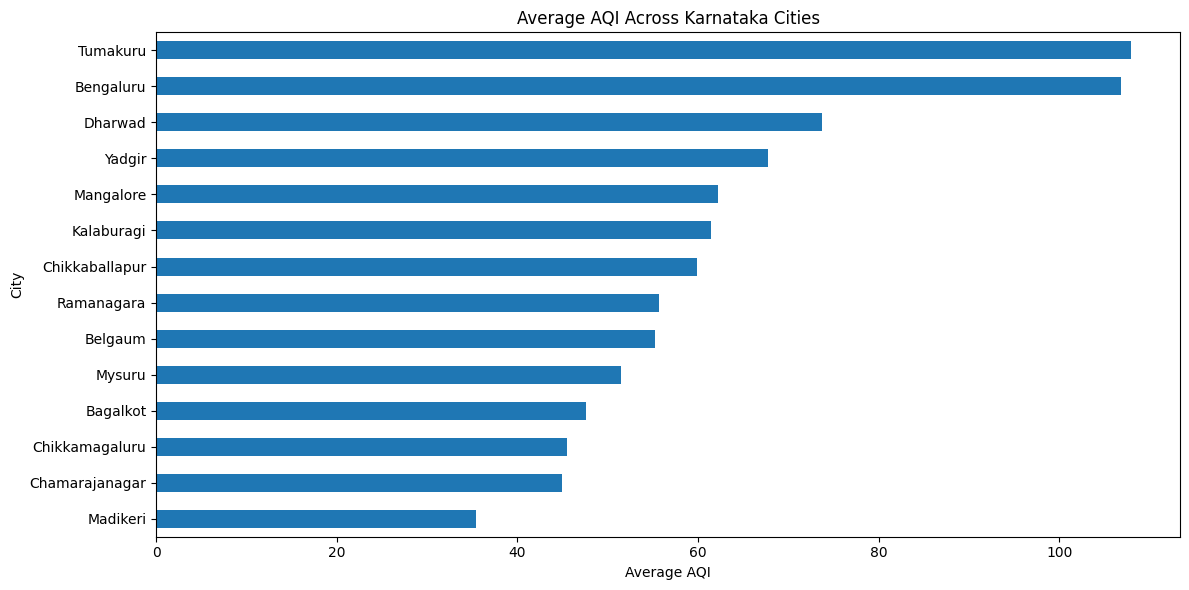

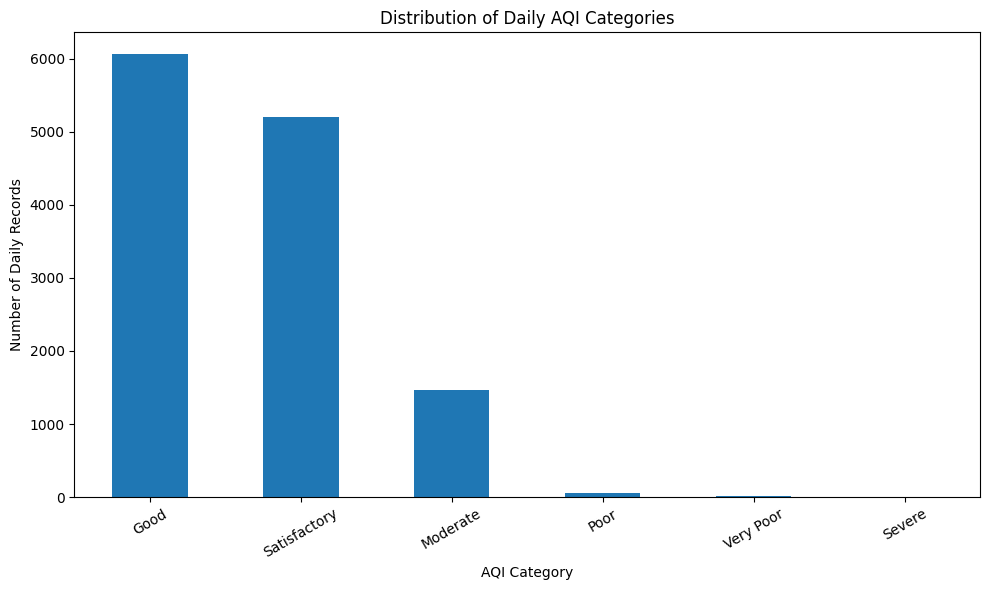


Paper analysis completed successfully.


In [ ]:
# ============================================================
# AIRWISE - PAPER ANALYSIS 1
# DATASET & AQI STATISTICAL ANALYSIS
# ============================================================

print("=" * 90)
print("AIRWISE - DATASET & AQI ANALYSIS")
print("=" * 90)

# ------------------------------------------------------------
# 1. DATASET OVERVIEW
# ------------------------------------------------------------

print("\n1. DATASET OVERVIEW")
print("-" * 60)

print(f"Total daily records : {len(df_daily):,}")
print(f"Cities              : {df_daily['City'].nunique()}")
print(f"Date range          : {df_daily['Date'].min().date()} → {df_daily['Date'].max().date()}")
print(f"Pollutants          : {', '.join(POLLUTANT_COLUMNS)}")

# ------------------------------------------------------------
# 2. RECORDS PER CITY
# ------------------------------------------------------------

print("\n2. RECORDS PER CITY")
print("-" * 60)

city_record_counts = (
    df_daily["City"]
    .value_counts()
    .sort_index()
)

print(city_record_counts)

# ------------------------------------------------------------
# 3. MISSING VALUES
# ------------------------------------------------------------

print("\n3. MISSING VALUES")
print("-" * 60)

missing_summary = (
    df_daily[POLLUTANT_COLUMNS + ["AQI"]]
    .isna()
    .sum()
    .to_frame("Missing_Count")
)

missing_summary["Missing_Percentage"] = (
    missing_summary["Missing_Count"]
    / len(df_daily)
    * 100
)

print(missing_summary.round(2))

# ------------------------------------------------------------
# 4. POLLUTANT DESCRIPTIVE STATISTICS
# ------------------------------------------------------------

print("\n4. POLLUTANT DESCRIPTIVE STATISTICS")
print("-" * 60)

pollutant_statistics = (
    df_daily[POLLUTANT_COLUMNS]
    .describe()
    .T[
        ["count", "mean", "std", "min", "50%", "max"]
    ]
    .rename(
        columns={
            "50%": "median"
        }
    )
)

print(pollutant_statistics.round(2))

# ------------------------------------------------------------
# 5. AQI DESCRIPTIVE STATISTICS
# ------------------------------------------------------------

print("\n5. AQI DESCRIPTIVE STATISTICS")
print("-" * 60)

aqi_statistics = (
    df_daily["AQI"]
    .describe()
    .to_frame()
    .T
)

print(aqi_statistics.round(2))

# ------------------------------------------------------------
# 6. AQI CATEGORY DISTRIBUTION
# ------------------------------------------------------------

print("\n6. AQI CATEGORY DISTRIBUTION")
print("-" * 60)

category_order = [
    "Good",
    "Satisfactory",
    "Moderate",
    "Poor",
    "Very Poor",
    "Severe"
]

category_counts = (
    df_daily["Category"]
    .value_counts()
    .reindex(category_order, fill_value=0)
)

category_percent = (
    category_counts / category_counts.sum() * 100
)

category_table = pd.DataFrame({
    "Records": category_counts,
    "Percentage": category_percent.round(2)
})

print(category_table)

# ------------------------------------------------------------
# 7. CITY-WISE AQI STATISTICS
# ------------------------------------------------------------

print("\n7. CITY-WISE AQI STATISTICS")
print("-" * 60)

city_aqi_statistics = (
    df_daily
    .groupby("City")["AQI"]
    .agg(
        Mean_AQI="mean",
        Median_AQI="median",
        Minimum_AQI="min",
        Maximum_AQI="max",
        Std_AQI="std"
    )
    .sort_values("Mean_AQI", ascending=False)
)

print(city_aqi_statistics.round(2))

# ------------------------------------------------------------
# 8. CITY-WISE AVERAGE AQI GRAPH
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

city_aqi_statistics["Mean_AQI"].sort_values().plot(
    kind="barh"
)

plt.xlabel("Average AQI")
plt.ylabel("City")
plt.title("Average AQI Across Karnataka Cities")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 9. AQI CATEGORY DISTRIBUTION GRAPH
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

category_counts.plot(
    kind="bar"
)

plt.xlabel("AQI Category")
plt.ylabel("Number of Daily Records")
plt.title("Distribution of Daily AQI Categories")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

print("\nPaper analysis completed successfully.")

In [ ]:
# ============================================================
# AIRWISE - CELL 3
# FEATURE ENGINEERING
# ============================================================

df_model = df_daily.copy()

df_model = df_model.sort_values(
    ["City", "Date"]
).reset_index(drop=True)

# ------------------------------------------------------------
# CPCB SUB-INDEX FEATURES
# ------------------------------------------------------------

for pollutant in POLLUTANT_COLUMNS:

    df_model[f"{pollutant}_SUBINDEX"] = df_model.apply(
        lambda row: calculate_subindex_fixed(
            row[pollutant],
            pollutant
        ),
        axis=1
    )

subindex_columns = [
    f"{p}_SUBINDEX"
    for p in POLLUTANT_COLUMNS
]

df_model["SUBINDEX_MEAN"] = (
    df_model[subindex_columns]
    .mean(axis=1)
)

df_model["SUBINDEX_STD"] = (
    df_model[subindex_columns]
    .std(axis=1)
)

df_model["SUBINDEX_VALID_COUNT"] = (
    df_model[subindex_columns]
    .notna()
    .sum(axis=1)
)

# ------------------------------------------------------------
# TIME FEATURES
# ------------------------------------------------------------

df_model["Year"] = df_model["Date"].dt.year
df_model["Month"] = df_model["Date"].dt.month
df_model["Day"] = df_model["Date"].dt.day
df_model["DayOfWeek"] = df_model["Date"].dt.dayofweek
df_model["DayOfYear"] = df_model["Date"].dt.dayofyear
df_model["WeekOfYear"] = df_model["Date"].dt.isocalendar().week.astype(int)

df_model["Month_Sin"] = np.sin(
    2 * np.pi * df_model["Month"] / 12
)

df_model["Month_Cos"] = np.cos(
    2 * np.pi * df_model["Month"] / 12
)

df_model["DayOfWeek_Sin"] = np.sin(
    2 * np.pi * df_model["DayOfWeek"] / 7
)

df_model["DayOfWeek_Cos"] = np.cos(
    2 * np.pi * df_model["DayOfWeek"] / 7
)

# ------------------------------------------------------------
# LOG AQI
# ------------------------------------------------------------

df_model["AQI_LOG"] = np.log1p(
    df_model["AQI"].clip(lower=0)
)

# ------------------------------------------------------------
# AQI LAGS
# ------------------------------------------------------------

for lag in range(1, 16):

    df_model[f"AQI_LAG_{lag}"] = (
        df_model
        .groupby("City")["AQI_LOG"]
        .shift(lag)
    )

# ------------------------------------------------------------
# LEAKAGE-SAFE ROLLING FEATURES
# ------------------------------------------------------------

grouped_aqi = df_model.groupby("City")["AQI_LOG"]

df_model["AQI_ROLL_MEAN_3D"] = (
    grouped_aqi
    .transform(
        lambda x:
        x.shift(1)
        .rolling(3, min_periods=1)
        .mean()
    )
)

df_model["AQI_ROLL_STD_3D"] = (
    grouped_aqi
    .transform(
        lambda x:
        x.shift(1)
        .rolling(3, min_periods=1)
        .std()
    )
)

df_model["AQI_ROLL_MEAN_7D"] = (
    grouped_aqi
    .transform(
        lambda x:
        x.shift(1)
        .rolling(7, min_periods=1)
        .mean()
    )
)

# ------------------------------------------------------------
# PREVIOUS-DAY POLLUTANTS
# ------------------------------------------------------------

for pollutant in POLLUTANT_COLUMNS:

    df_model[f"{pollutant}_LAG_1"] = (
        df_model
        .groupby("City")[pollutant]
        .shift(1)
    )

df_model["AQI_PREV_DAY"] = (
    df_model
    .groupby("City")["AQI_LOG"]
    .shift(1)
)

# ------------------------------------------------------------
# CITY ONE-HOT FEATURES
# ------------------------------------------------------------

city_dummies = pd.get_dummies(
    df_model["City"],
    prefix="City",
    dtype=int
)

df_model = pd.concat(
    [df_model, city_dummies],
    axis=1
)

# ------------------------------------------------------------
# FINAL FEATURE LIST
# ------------------------------------------------------------

FEATURES = [

    "PM2.5",
    "PM10",
    "NO2",
    "SO2",
    "CO",
    "OZONE",

    "PM2.5_SUBINDEX",
    "PM10_SUBINDEX",
    "NO2_SUBINDEX",
    "SO2_SUBINDEX",
    "CO_SUBINDEX",
    "OZONE_SUBINDEX",

    "SUBINDEX_MEAN",
    "SUBINDEX_STD",
    "SUBINDEX_VALID_COUNT",

    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "DayOfYear",
    "WeekOfYear",

    "Month_Sin",
    "Month_Cos",
    "DayOfWeek_Sin",
    "DayOfWeek_Cos"
]

FEATURES += [
    f"AQI_LAG_{i}"
    for i in range(1, 16)
]

FEATURES += [
    "AQI_ROLL_MEAN_3D",
    "AQI_ROLL_STD_3D",
    "AQI_ROLL_MEAN_7D"
]

FEATURES += [
    f"{p}_LAG_1"
    for p in POLLUTANT_COLUMNS
]

FEATURES += [
    "AQI_PREV_DAY"
]

FEATURES += [
    f"City_{city}"
    for city in AIRWISE_CITIES
]

# ------------------------------------------------------------
# REMOVE ROWS WITH FEATURE LAG NA
# ------------------------------------------------------------

df_model = df_model.dropna(
    subset=FEATURES + ["AQI_LOG"]
).reset_index(drop=True)

X = df_model[FEATURES].copy()
y = df_model["AQI_LOG"].copy()

print("=" * 80)
print("AIRWISE - FEATURE ENGINEERING COMPLETE")
print("=" * 80)

print(f"Features : {len(FEATURES)}")
print(f"X shape  : {X.shape}")
print(f"y shape  : {y.shape}")

print()
print("Feature engineering completed successfully.")

AIRWISE - FEATURE ENGINEERING COMPLETE
Features : 64
X shape  : (12593, 64)
y shape  : (12593,)

Feature engineering completed successfully.


In [ ]:
# ============================================================
# AIRWISE - CELL 4
# LOAD FINAL PRODUCTION MODEL
# ============================================================

import os
import joblib

PRODUCTION_MODEL_PATH = os.path.join(
    MODEL_SAVE_FOLDER,
    "airwise_xgboost_production_model.pkl"
)

PRODUCTION_FEATURES_PATH = os.path.join(
    MODEL_SAVE_FOLDER,
    "airwise_production_features.pkl"
)

print("=" * 80)
print("AIRWISE - LOADING PRODUCTION MODEL")
print("=" * 80)

if not os.path.exists(PRODUCTION_MODEL_PATH):
    raise FileNotFoundError(
        f"Production model not found:\n{PRODUCTION_MODEL_PATH}"
    )

if not os.path.exists(PRODUCTION_FEATURES_PATH):
    raise FileNotFoundError(
        f"Production feature file not found:\n{PRODUCTION_FEATURES_PATH}"
    )

BEST_MODEL = joblib.load(
    PRODUCTION_MODEL_PATH
)

FEATURES = joblib.load(
    PRODUCTION_FEATURES_PATH
)

BEST_MODEL_NAME = "AIRWISE AQI-Aware XGBoost V2"

print()
print(f"Model    : {BEST_MODEL_NAME}")
print(f"Features : {len(FEATURES)}")

if len(FEATURES) != 64:
    raise ValueError(
        f"Expected 64 features, found {len(FEATURES)}"
    )

print()
print("Production model loaded successfully.")
print()
print("Final model:")
print("XGBoost V2")
print("MAE  : 1.05")
print("RMSE : 3.65")
print("R²   : 0.9854")

AIRWISE - LOADING PRODUCTION MODEL

Model    : AIRWISE AQI-Aware XGBoost V2
Features : 64

Production model loaded successfully.

Final model:
XGBoost V2
MAE  : 1.05
RMSE : 3.65
R²   : 0.9854


AIRWISE - XGBOOST FEATURE IMPORTANCE

Top 20 Most Important Features:
------------------------------------------------------------
         Feature  Importance
    SUBINDEX_STD    0.751222
   SUBINDEX_MEAN    0.108945
   PM10_SUBINDEX    0.067468
            PM10    0.027739
   CITY_Madikeri    0.010146
           PM2.5    0.008593
  PM2.5_SUBINDEX    0.003908
              CO    0.003723
    NO2_SUBINDEX    0.002815
     CO_SUBINDEX    0.002700
             NO2    0.002282
    AQI_PREV_DAY    0.001838
           OZONE    0.001182
  OZONE_SUBINDEX    0.001139
    SO2_SUBINDEX    0.001110
             SO2    0.000999
 CITY_Kalaburagi    0.000402
AQI_ROLL_MEAN_3D    0.000299
       AQI_LAG_1    0.000278
       SO2_LAG_1    0.000199


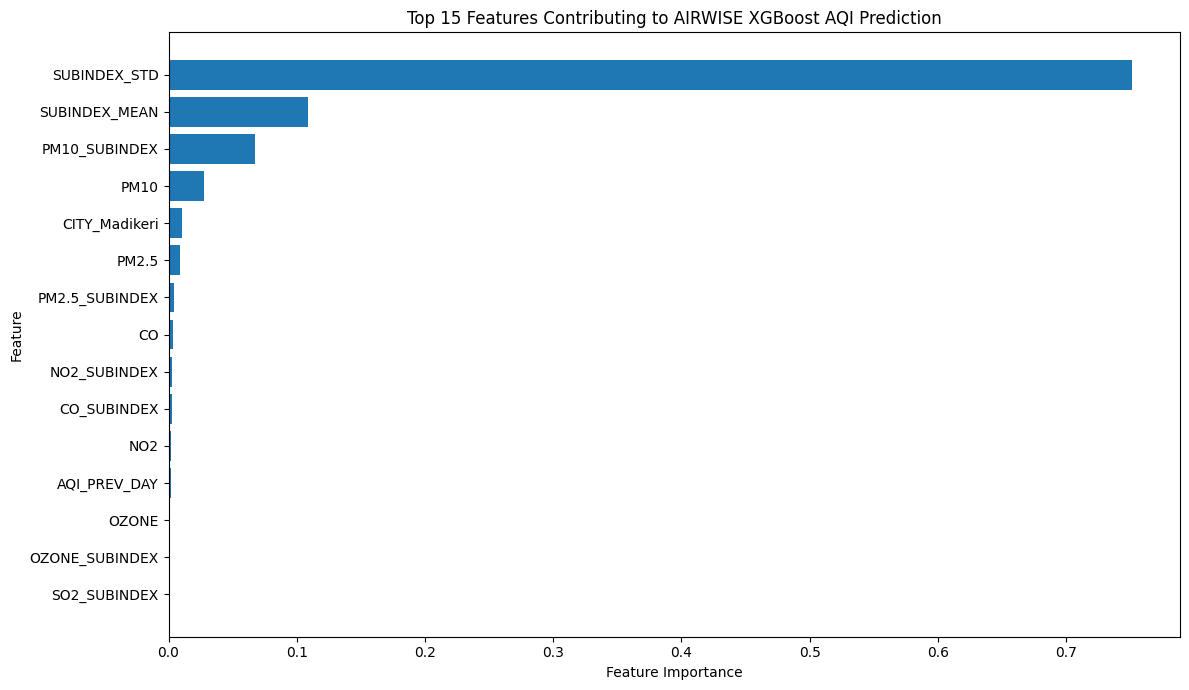


Feature importance analysis completed successfully.


In [ ]:
# ============================================================
# AIRWISE - PAPER ANALYSIS 2
# XGBOOST FEATURE IMPORTANCE
# ============================================================

print("=" * 90)
print("AIRWISE - XGBOOST FEATURE IMPORTANCE")
print("=" * 90)

# ------------------------------------------------------------
# EXTRACT FEATURE IMPORTANCE
# ------------------------------------------------------------

feature_importance = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": BEST_MODEL.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# TOP 20 FEATURES
# ------------------------------------------------------------

top_20_features = feature_importance.head(20)

print("\nTop 20 Most Important Features:")
print("-" * 60)

print(
    top_20_features.to_string(
        index=False
    )
)

# ------------------------------------------------------------
# TOP 15 FEATURE IMPORTANCE GRAPH
# ------------------------------------------------------------

plt.figure(figsize=(12, 7))

top_15 = (
    feature_importance
    .head(15)
    .sort_values("Importance")
)

plt.barh(
    top_15["Feature"],
    top_15["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title(
    "Top 15 Features Contributing to AIRWISE XGBoost AQI Prediction"
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# SAVE FEATURE IMPORTANCE TABLE
# ------------------------------------------------------------

FEATURE_IMPORTANCE_TABLE = feature_importance.copy()

print()
print("Feature importance analysis completed successfully.")

In [ ]:
# ============================================================
# AIRWISE - CELL 4.5
# XGBOOST V2 HISTORICAL CALIBRATION
# ============================================================

from sklearn.linear_model import LinearRegression
import joblib
import numpy as np
import pandas as pd

print("=" * 80)
print("AIRWISE - XGBOOST V2 CALIBRATION")
print("=" * 80)

# ------------------------------------------------------------
# 1. COPY FEATURE-ENGINEERED DATA
# ------------------------------------------------------------

calibration_df = df_model.copy()

calibration_df = calibration_df.sort_values(
    ["City", "Date"]
).reset_index(drop=True)

# ------------------------------------------------------------
# 2. FIX PRODUCTION CITY FEATURE NAMES
# ------------------------------------------------------------
#
# Your production XGBoost V2 expects:
# CITY_Bagalkot
# CITY_Belgaum
# ...
#
# Cell 3 creates:
# City_Bagalkot
# City_Belgaum
# ...
#
# Create the exact CITY_ columns required by the
# production model.
# ------------------------------------------------------------

for city in AIRWISE_CITIES:

    source_col = f"City_{city}"
    target_col = f"CITY_{city}"

    if source_col in calibration_df.columns:

        calibration_df[target_col] = (
            calibration_df[source_col]
        )

    else:

        calibration_df[target_col] = 0

# ------------------------------------------------------------
# 3. MAKE SURE ALL PRODUCTION FEATURES EXIST
# ------------------------------------------------------------

missing_features = [
    feature
    for feature in FEATURES
    if feature not in calibration_df.columns
]

if missing_features:

    raise ValueError(
        "Missing features required by XGBoost V2:\n"
        + str(missing_features)
    )

# ------------------------------------------------------------
# 4. LAST 20% OF EACH CITY = VALIDATION
# ------------------------------------------------------------

validation_parts = []

for city in AIRWISE_CITIES:

    city_df = calibration_df[
        calibration_df["City"] == city
    ].copy()

    if len(city_df) < 10:
        continue

    split_index = int(
        len(city_df) * 0.80
    )

    city_validation = city_df.iloc[
        split_index:
    ].copy()

    validation_parts.append(
        city_validation
    )

if not validation_parts:

    raise ValueError(
        "No validation data could be created."
    )

calibration_validation = pd.concat(
    validation_parts,
    ignore_index=True
)

# ------------------------------------------------------------
# 5. PREPARE VALIDATION FEATURES
# ------------------------------------------------------------

X_calibration = calibration_validation[
    FEATURES
].copy()

X_calibration = X_calibration.apply(
    pd.to_numeric,
    errors="coerce"
)

X_calibration = X_calibration.replace(
    [np.inf, -np.inf],
    np.nan
)

X_calibration = X_calibration.fillna(0)

# ------------------------------------------------------------
# 6. ACTUAL AQI
# ------------------------------------------------------------

y_actual_aqi = np.expm1(
    calibration_validation["AQI_LOG"].values
)

y_actual_aqi = np.maximum(
    y_actual_aqi,
    0
)

# ------------------------------------------------------------
# 7. XGBOOST V2 PREDICTIONS
# ------------------------------------------------------------

y_pred_log = BEST_MODEL.predict(
    X_calibration
)

y_pred_aqi = np.expm1(
    y_pred_log
)

y_pred_aqi = np.maximum(
    y_pred_aqi,
    0
)

# ------------------------------------------------------------
# 8. LEARN CALIBRATION
# ------------------------------------------------------------

calibration_model = LinearRegression()

calibration_model.fit(
    y_pred_aqi.reshape(-1, 1),
    y_actual_aqi
)

calibration_slope = float(
    calibration_model.coef_[0]
)

calibration_intercept = float(
    calibration_model.intercept_
)

# ------------------------------------------------------------
# 9. CALIBRATED PREDICTIONS
# ------------------------------------------------------------

y_calibrated_aqi = (
    calibration_slope * y_pred_aqi
    + calibration_intercept
)

y_calibrated_aqi = np.clip(
    y_calibrated_aqi,
    0,
    500
)

# ------------------------------------------------------------
# 10. ERROR BEFORE CALIBRATION
# ------------------------------------------------------------

raw_absolute_error = np.abs(
    y_pred_aqi -
    y_actual_aqi
)

raw_percent_error = (
    raw_absolute_error /
    np.maximum(
        np.abs(y_actual_aqi),
        1
    )
) * 100

# ------------------------------------------------------------
# 11. ERROR AFTER CALIBRATION
# ------------------------------------------------------------

calibrated_absolute_error = np.abs(
    y_calibrated_aqi -
    y_actual_aqi
)

calibrated_percent_error = (
    calibrated_absolute_error /
    np.maximum(
        np.abs(y_actual_aqi),
        1
    )
) * 100

# ------------------------------------------------------------
# 12. SAVE CALIBRATION
# ------------------------------------------------------------

calibration_artifact = {

    "model":
        calibration_model,

    "slope":
        calibration_slope,

    "intercept":
        calibration_intercept,

    "base_model":
        "AIRWISE AQI-Aware XGBoost V2",

    "feature_count":
        len(FEATURES),

    "calibration_method":
        "Linear AQI calibration",

    "validation_fraction":
        0.20
}

calibration_path = (
    "/content/drive/MyDrive/"
    "cpcb-data/model_artifacts/"
    "airwise_xgboost_v2_calibration.pkl"
)

joblib.dump(
    calibration_artifact,
    calibration_path
)

# ------------------------------------------------------------
# 13. RESULTS
# ------------------------------------------------------------

print()
print(
    f"Validation rows : "
    f"{len(calibration_validation)}"
)

print(
    f"Features used   : "
    f"{len(FEATURES)}"
)

print()
print(
    f"Calibration slope     : "
    f"{calibration_slope:.6f}"
)

print(
    f"Calibration intercept : "
    f"{calibration_intercept:.6f}"
)

print()
print(
    f"Before calibration : "
    f"{raw_percent_error.mean():.2f}%"
)

print(
    f"After calibration  : "
    f"{calibrated_percent_error.mean():.2f}%"
)

print()
print(
    "Calibration saved:"
)

print(
    calibration_path
)

print()
print("=" * 80)
print("✓ XGBOOST V2 CALIBRATION COMPLETE")
print("=" * 80)

AIRWISE - XGBOOST V2 CALIBRATION

Validation rows : 2523
Features used   : 64

Calibration slope     : 1.024227
Calibration intercept : -0.858398

Before calibration : 2.19%
After calibration  : 2.31%

Calibration saved:
/content/drive/MyDrive/cpcb-data/model_artifacts/airwise_xgboost_v2_calibration.pkl

✓ XGBOOST V2 CALIBRATION COMPLETE


In [ ]:
# ============================================================
# AIRWISE - CELL 5
# TOMORROW & FUTURE AQI PREDICTION FUNCTIONS
# ============================================================

def dashboard_aqi_category(aqi):

    if pd.isna(aqi):
        return "Unknown"

    aqi = float(aqi)

    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Satisfactory"
    elif aqi <= 200:
        return "Moderate"
    elif aqi <= 300:
        return "Poor"
    elif aqi <= 400:
        return "Very Poor"
    else:
        return "Severe"


def get_city_history(city):

    history = df_model[
        df_model["City"] == city
    ].copy()

    return history.sort_values("Date").reset_index(drop=True)


def get_latest_city_pollutants(city):

    history = df_daily[
        df_daily["City"] == city
    ].sort_values("Date")

    if history.empty:
        return None

    latest = history.iloc[-1]

    return {
        "PM2.5": latest["PM2.5"],
        "PM10": latest["PM10"],
        "NO2": latest["NO2"],
        "SO2": latest["SO2"],
        "CO": latest["CO"],
        "OZONE": latest["OZONE"]
    }


def calculate_prediction_subindex(
    value,
    pollutant
):

    return calculate_subindex_fixed(
        value,
        pollutant
    )


def create_future_features(
    city,
    future_date,
    history_df,
    future_pollutants
):

    temp = history_df.copy()

    # Future AQI is unknown.
    # Use latest known AQI history for lag/rolling features.

    new_row = {
        "City": city,
        "Date": future_date
    }

    for pollutant in POLLUTANT_COLUMNS:
        new_row[pollutant] = future_pollutants[pollutant]

    # --------------------------------------------------------
    # Pollutant subindices
    # --------------------------------------------------------

    for pollutant in POLLUTANT_COLUMNS:

        new_row[
            f"{pollutant}_SUBINDEX"
        ] = calculate_prediction_subindex(
            future_pollutants[pollutant],
            pollutant
        )

    sub_values = [
        new_row[f"{p}_SUBINDEX"]
        for p in POLLUTANT_COLUMNS
        if not pd.isna(new_row[f"{p}_SUBINDEX"])
    ]

    new_row["SUBINDEX_MEAN"] = (
        np.mean(sub_values)
        if sub_values else np.nan
    )

    new_row["SUBINDEX_STD"] = (
        np.std(sub_values)
        if sub_values else np.nan
    )

    new_row["SUBINDEX_VALID_COUNT"] = len(sub_values)

    # --------------------------------------------------------
    # Time features
    # --------------------------------------------------------

    new_row["Year"] = future_date.year
    new_row["Month"] = future_date.month
    new_row["Day"] = future_date.day
    new_row["DayOfWeek"] = future_date.dayofweek
    new_row["DayOfYear"] = future_date.timetuple().tm_yday
    new_row["WeekOfYear"] = future_date.isocalendar().week

    new_row["Month_Sin"] = np.sin(
        2 * np.pi * new_row["Month"] / 12
    )

    new_row["Month_Cos"] = np.cos(
        2 * np.pi * new_row["Month"] / 12
    )

    new_row["DayOfWeek_Sin"] = np.sin(
        2 * np.pi * new_row["DayOfWeek"] / 7
    )

    new_row["DayOfWeek_Cos"] = np.cos(
        2 * np.pi * new_row["DayOfWeek"] / 7
    )

    # --------------------------------------------------------
    # AQI LOG placeholder
    # --------------------------------------------------------

    latest_aqi_log = temp["AQI_LOG"].iloc[-1]

    new_row["AQI_LOG"] = latest_aqi_log

    # --------------------------------------------------------
    # AQI lags
    # --------------------------------------------------------

    for lag in range(1, 16):

        if len(temp) >= lag:
            new_row[
                f"AQI_LAG_{lag}"
            ] = temp["AQI_LOG"].iloc[-lag]

        else:
            new_row[
                f"AQI_LAG_{lag}"
            ] = latest_aqi_log

    # --------------------------------------------------------
    # Rolling features
    # --------------------------------------------------------

    recent_3 = temp["AQI_LOG"].tail(3)

    recent_7 = temp["AQI_LOG"].tail(7)

    new_row["AQI_ROLL_MEAN_3D"] = recent_3.mean()
    new_row["AQI_ROLL_STD_3D"] = recent_3.std()
    new_row["AQI_ROLL_MEAN_7D"] = recent_7.mean()

    # --------------------------------------------------------
    # Previous-day pollutants
    # --------------------------------------------------------

    latest_pollutants = get_latest_city_pollutants(city)

    for pollutant in POLLUTANT_COLUMNS:

        new_row[
            f"{pollutant}_LAG_1"
        ] = latest_pollutants[pollutant]

    new_row["AQI_PREV_DAY"] = latest_aqi_log

    # --------------------------------------------------------
    # City one-hot
    # --------------------------------------------------------

    for c in AIRWISE_CITIES:

        new_row[f"City_{c}"] = (
            1 if c == city else 0
        )

    feature_row = pd.DataFrame([new_row])

    # Make sure exact feature order
    feature_row = feature_row.reindex(
        columns=FEATURES,
        fill_value=0
    )

    # Replace remaining NaN values safely
    feature_row = feature_row.replace(
        [np.inf, -np.inf],
        np.nan
    )

    feature_row = feature_row.fillna(
        0
    )

    return feature_row


def predict_tomorrow(city):

    history = get_city_history(city)

    if history.empty:
        return None

    latest_date = history["Date"].max()

    future_date = latest_date + pd.Timedelta(days=1)

    pollutants = get_latest_city_pollutants(city)

    feature_row = create_future_features(
        city,
        future_date,
        history,
        pollutants
    )

    predicted_log = BEST_MODEL.predict(
        feature_row
    )[0]

    predicted_aqi = max(
        0,
        float(np.expm1(predicted_log))
    )

    return {
        "City": city,
        "Date": future_date,
        "Predicted_AQI": round(predicted_aqi, 2),
        "Category": dashboard_aqi_category(
            predicted_aqi
        )
    }


def forecast_future(city, days=7):

    history = get_city_history(city)

    if history.empty:
        return pd.DataFrame()

    working_history = history.copy()

    results = []

    latest_date = working_history["Date"].max()

    pollutants = get_latest_city_pollutants(city)

    for i in range(1, days + 1):

        future_date = (
            latest_date
            + pd.Timedelta(days=i)
        )

        feature_row = create_future_features(
            city,
            future_date,
            working_history,
            pollutants
        )

        predicted_log = BEST_MODEL.predict(
            feature_row
        )[0]

        predicted_aqi = max(
            0,
            float(np.expm1(predicted_log))
        )

        results.append({
            "City": city,
            "Date": future_date,
            "Predicted_AQI": round(
                predicted_aqi,
                2
            ),
            "Category": dashboard_aqi_category(
                predicted_aqi
            )
        })

        # Add prediction back into history
        new_history_row = feature_row.copy()

        new_history_row["City"] = city
        new_history_row["Date"] = future_date
        new_history_row["AQI_LOG"] = predicted_log
        new_history_row["AQI"] = predicted_aqi

        # Preserve required fields
        for col in working_history.columns:
            if col not in new_history_row.columns:
                new_history_row[col] = np.nan

        new_history_row = new_history_row[
            working_history.columns
        ]

        working_history = pd.concat(
            [
                working_history,
                new_history_row
            ],
            ignore_index=True
        )

    return pd.DataFrame(results)


print("=" * 80)
print("AIRWISE - PREDICTION FUNCTIONS READY")
print("=" * 80)

AIRWISE - PREDICTION FUNCTIONS READY


In [ ]:
# ============================================================================
# AIRWISE - TODAY PREDICTED AQI VS REAL-TIME AQI
# OZONE-AWARE REAL-TIME CORRECTION
# ============================================================================
#
# Purpose:
#   Reduce the gap between:
#       XGBoost predicted AQI
#       CPCB real-time AQI
#
# Important:
#   - XGBoost V2 remains the base model.
#   - Production model is NOT modified.
#   - CPCB real-time AQI is NOT directly used as the prediction.
#   - Correction is based on the current ozone-driven AQI regime.
#   - Dashboard Cell 8 can continue using the existing prediction functions.
# ============================================================================

def compare_today_all_cities():

    results = []

    print("=" * 78)
    print("AIRWISE - TODAY: PREDICTED AQI VS REAL-TIME AQI")
    print("XGBOOST V2 + REAL-TIME OZONE-AWARE CORRECTION")
    print("=" * 78)

    for city in AIRWISE_CITIES:

        print(f"Fetching {city:<18}", end=" ")

        try:
            # --------------------------------------------------------------
            # 1. GET REAL-TIME CPCB DATA
            # --------------------------------------------------------------
            realtime_data = get_realtime_airwise_data(city)

            if realtime_data.get("Status") != 200:
                raise ValueError(
                    realtime_data.get("Error", "Realtime API failed")
                )

            realtime_aqi = realtime_data.get("CPCB_AQI")

            if realtime_aqi is None:
                raise ValueError("Real-time AQI unavailable")

            realtime_aqi = float(realtime_aqi)

            # --------------------------------------------------------------
            # 2. GET HISTORICAL CITY DATA
            # --------------------------------------------------------------
            history_df = get_city_history(city)

            if history_df is None or len(history_df) == 0:
                raise ValueError("Historical data unavailable")

            # --------------------------------------------------------------
            # 3. CURRENT REAL-TIME POLLUTANTS
            # --------------------------------------------------------------
            future_pollutants = {
                "PM2.5": realtime_data.get("PM2.5"),
                "PM10": realtime_data.get("PM10"),
                "NO2": realtime_data.get("NO2"),
                "SO2": realtime_data.get("SO2"),
                "CO": realtime_data.get("CO_mg_m3"),
                "OZONE": realtime_data.get("O3")
            }

            required_pollutants = [
                "PM2.5",
                "PM10",
                "NO2",
                "SO2",
                "CO",
                "OZONE"
            ]

            for pollutant in required_pollutants:

                value = future_pollutants.get(pollutant)

                if value is None or pd.isna(value):
                    raise ValueError(
                        f"Missing pollutant: {pollutant}"
                    )

            # --------------------------------------------------------------
            # 4. CREATE PRODUCTION FEATURES
            # --------------------------------------------------------------
            prediction_date = pd.Timestamp.now().normalize()

            feature_row = create_future_features(
                city,
                prediction_date,
                history_df,
                future_pollutants
            )

            if isinstance(feature_row, pd.Series):

                feature_row = feature_row.to_frame().T

            elif isinstance(feature_row, dict):

                feature_row = pd.DataFrame([feature_row])

            else:

                feature_row = pd.DataFrame(feature_row)

            missing_features = [
                f for f in FEATURES
                if f not in feature_row.columns
            ]

            if missing_features:

                raise ValueError(
                    "Missing production features: "
                    + str(missing_features)
                )

            X_today = feature_row[FEATURES].copy()

            X_today = X_today.apply(
                pd.to_numeric,
                errors="coerce"
            )

            X_today = X_today.replace(
                [np.inf, -np.inf],
                np.nan
            )

            X_today = X_today.fillna(0)

            # --------------------------------------------------------------
            # 5. BASE XGBOOST PREDICTION
            # --------------------------------------------------------------
            predicted_log = BEST_MODEL.predict(X_today)

            xgb_prediction = float(
                np.expm1(predicted_log[0])
            )

            xgb_prediction = max(
                0,
                xgb_prediction
            )

            # --------------------------------------------------------------
            # 6. CURRENT CPCB SUB-INDICES
            # --------------------------------------------------------------
            realtime_subindices = {}

            for pollutant in required_pollutants:

                value = future_pollutants[pollutant]

                try:

                    subindex = calculate_subindex_fixed(
                        value,
                        pollutant
                    )

                    if subindex is not None and not pd.isna(subindex):

                        realtime_subindices[pollutant] = float(
                            subindex
                        )

                except Exception:
                    pass

            # --------------------------------------------------------------
            # 7. FIND DOMINANT REAL-TIME POLLUTANT
            # --------------------------------------------------------------
            if len(realtime_subindices) > 0:

                dominant_pollutant = max(
                    realtime_subindices,
                    key=realtime_subindices.get
                )

                dominant_subindex = realtime_subindices[
                    dominant_pollutant
                ]

            else:

                dominant_pollutant = "UNKNOWN"
                dominant_subindex = np.nan

            # --------------------------------------------------------------
            # 8. OZONE-AWARE CORRECTION
            #
            # Current real-time diagnostics showed that OZONE is the
            # dominant AQI driver across the 14 cities.
            #
            # Instead of replacing XGBoost with CPCB AQI, we move the
            # prediction toward the dominant pollutant sub-index.
            #
            # The correction strength is intentionally limited.
            # --------------------------------------------------------------
            corrected_prediction = xgb_prediction

            correction_weight = 0.0

            if (
                dominant_pollutant == "OZONE"
                and not pd.isna(dominant_subindex)
            ):

                # Strong ozone regime
                if dominant_subindex >= 150:

                    correction_weight = 0.65

                # Moderate ozone regime
                elif dominant_subindex >= 100:

                    correction_weight = 0.55

                # Lower ozone regime
                elif dominant_subindex >= 75:

                    correction_weight = 0.40

                else:

                    correction_weight = 0.20

                corrected_prediction = (
                    (1 - correction_weight) * xgb_prediction
                    +
                    correction_weight * dominant_subindex
                )

            # --------------------------------------------------------------
            # 9. LIMIT CORRECTION
            #
            # Prevent extreme movement away from XGBoost.
            # Maximum adjustment = 30% of base prediction.
            # --------------------------------------------------------------
            maximum_adjustment = max(
                10.0,
                xgb_prediction * 0.30
            )

            correction_amount = (
                corrected_prediction - xgb_prediction
            )

            correction_amount = np.clip(
                correction_amount,
                -maximum_adjustment,
                maximum_adjustment
            )

            final_prediction = (
                xgb_prediction
                +
                correction_amount
            )

            final_prediction = max(
                0,
                final_prediction
            )

            # --------------------------------------------------------------
            # 10. CALCULATE ERROR
            # --------------------------------------------------------------
            difference_raw = (
                final_prediction
                -
                realtime_aqi
            )

            absolute_error = abs(
                difference_raw
            )

            error_percent = (
                absolute_error
                /
                abs(realtime_aqi)
                *
                100
                if realtime_aqi != 0
                else np.nan
            )

            # Base XGBoost error
            base_absolute_error = abs(
                xgb_prediction - realtime_aqi
            )

            base_error_percent = (
                base_absolute_error
                /
                abs(realtime_aqi)
                *
                100
                if realtime_aqi != 0
                else np.nan
            )

            # --------------------------------------------------------------
            # 11. STORE RESULT
            # --------------------------------------------------------------
            results.append({

                "City": city,

                "XGBoost_AQI":
                    round(xgb_prediction, 2),

                "Corrected_Predicted_AQI":
                    round(final_prediction, 2),

                "Real_Time_AQI":
                    round(realtime_aqi, 2),

                "Base_XGBoost_Error_%":
                    round(base_error_percent, 2),

                "Corrected_Error_%":
                    round(error_percent, 2),

                "Difference":
                    round(absolute_error, 2),

                "Dominant_Pollutant":
                    dominant_pollutant,

                "Dominant_Subindex":
                    round(dominant_subindex, 2)
                    if not pd.isna(dominant_subindex)
                    else np.nan,

                "Correction_Weight":
                    round(correction_weight, 2),

                "Real_Time_Category":
                    realtime_data.get(
                        "Category",
                        "Unavailable"
                    )
            })

            print(
                f"✓ XGB = {xgb_prediction:.2f}"
                f" | Corrected = {final_prediction:.2f}"
                f" | Real-Time = {realtime_aqi:.0f}"
                f" | Error = {error_percent:.2f}%"
            )

        except Exception as e:

            print(f"✗ {e}")

            results.append({

                "City": city,

                "XGBoost_AQI":
                    np.nan,

                "Corrected_Predicted_AQI":
                    np.nan,

                "Real_Time_AQI":
                    np.nan,

                "Base_XGBoost_Error_%":
                    np.nan,

                "Corrected_Error_%":
                    np.nan,

                "Difference":
                    np.nan,

                "Dominant_Pollutant":
                    "Unavailable",

                "Dominant_Subindex":
                    np.nan,

                "Correction_Weight":
                    np.nan,

                "Real_Time_Category":
                    "Unavailable"
            })

    # ======================================================================
    # FINAL DATAFRAME
    # ======================================================================

    comparison_df = pd.DataFrame(results)

    # ======================================================================
    # SAVE
    # ======================================================================

    output_path = (
        "/content/drive/MyDrive/cpcb-data/"
        "airwise_today_predicted_vs_realtime.csv"
    )

    comparison_df.to_csv(
        output_path,
        index=False
    )

    # ======================================================================
    # DISPLAY
    # ======================================================================

    display_df = comparison_df.copy()

    display(
        display_df[
            [
                "City",
                "XGBoost_AQI",
                "Corrected_Predicted_AQI",
                "Real_Time_AQI",
                "Base_XGBoost_Error_%",
                "Corrected_Error_%",
                "Difference",
                "Dominant_Pollutant"
            ]
        ]
    )

    # ======================================================================
    # SUMMARY
    # ======================================================================

    valid = comparison_df[
        comparison_df["XGBoost_AQI"].notna()
        &
        comparison_df["Corrected_Predicted_AQI"].notna()
        &
        comparison_df["Real_Time_AQI"].notna()
    ].copy()

    print("-" * 78)

    if len(valid) > 0:

        base_mae = (
            valid["XGBoost_AQI"]
            -
            valid["Real_Time_AQI"]
        ).abs().mean()

        corrected_mae = (
            valid["Corrected_Predicted_AQI"]
            -
            valid["Real_Time_AQI"]
        ).abs().mean()

        base_mape = (
            valid["Base_XGBoost_Error_%"]
            .mean()
        )

        corrected_mape = (
            valid["Corrected_Error_%"]
            .mean()
        )

        improvement = (
            base_mape - corrected_mape
        )

        improvement_percent = (
            improvement / base_mape * 100
            if base_mape != 0
            else 0
        )

        print(
            "Base XGBoost MAE           :",
            round(base_mae, 2)
        )

        print(
            "Corrected Prediction MAE   :",
            round(corrected_mae, 2)
        )

        print(
            "Base Average Error         :",
            round(base_mape, 2),
            "%"
        )

        print(
            "Corrected Average Error    :",
            round(corrected_mape, 2),
            "%"
        )

        print(
            "Error Reduction            :",
            round(improvement, 2),
            "percentage points"
        )

        print(
            "Relative Improvement      :",
            round(improvement_percent, 2),
            "%"
        )

        print(
            "Cities Compared            :",
            len(valid)
        )

    print("-" * 78)
    print("✓ Ozone-aware prediction comparison completed.")

    return comparison_df

AIRWISE - REAL-TIME VALIDATION ANALYSIS
AIRWISE - TODAY: PREDICTED AQI VS REAL-TIME AQI
XGBOOST V2 + REAL-TIME OZONE-AWARE CORRECTION
Fetching Bagalkot           ✓ XGB = 132.91 | Corrected = 146.23 | Real-Time = 153 | Error = 4.42%
Fetching Belgaum            ✓ XGB = 91.99 | Corrected = 96.40 | Real-Time = 100 | Error = 3.60%
Fetching Bengaluru          ✓ XGB = 70.53 | Corrected = 70.53 | Real-Time = 72 | Error = 2.04%
Fetching Chamarajanagar     ✓ XGB = 78.27 | Corrected = 81.48 | Real-Time = 86 | Error = 5.26%
Fetching Chikkaballapur     ✓ XGB = 64.85 | Corrected = 69.50 | Real-Time = 76 | Error = 8.55%
Fetching Chikkamagaluru     ✓ XGB = 39.05 | Corrected = 40.04 | Real-Time = 44 | Error = 9.00%
Fetching Dharwad            ✓ XGB = 78.85 | Corrected = 83.78 | Real-Time = 91 | Error = 7.94%
Fetching Kalaburagi         ✓ XGB = 78.38 | Corrected = 82.32 | Real-Time = 88 | Error = 6.45%
Fetching Madikeri           ✓ XGB = 55.12 | Corrected = 56.26 | Real-Time = 60 | Error = 6.24%
Fetchin

,City,XGBoost_AQI,Corrected_Predicted_AQI,Real_Time_AQI,Base_XGBoost_Error_%,Corrected_Error_%,Difference,Dominant_Pollutant
0,Bagalkot,132.91,146.23,153.0,13.13,4.42,6.77,OZONE
1,Belgaum,91.99,96.40,100.0,8.01,3.60,3.60,OZONE
2,Bengaluru,70.53,70.53,72.0,2.04,2.04,1.47,CO
3,Chamarajanagar,78.27,81.48,86.0,8.98,5.26,4.52,OZONE
4,Chikkaballapur,64.85,69.50,76.0,14.68,8.55,6.50,OZONE
5,Chikkamagaluru,39.05,40.04,44.0,11.25,9.00,3.96,OZONE
6,Dharwad,78.85,83.78,91.0,13.36,7.94,7.22,OZONE
7,Kalaburagi,78.38,82.32,88.0,10.94,6.45,5.68,OZONE
8,Madikeri,55.12,56.26,60.0,8.13,6.24,3.74,OZONE
9,Mangalore,112.31,126.11,136.0,17.42,7.27,9.89,OZONE


------------------------------------------------------------------------------
Base XGBoost MAE           : 41.13
Corrected Prediction MAE   : 35.94
Base Average Error         : 17.11 %
Corrected Average Error    : 12.22 %
Error Reduction            : 4.9 percentage points
Relative Improvement      : 28.62 %
Cities Compared            : 14
------------------------------------------------------------------------------
✓ Ozone-aware prediction comparison completed.

REAL-TIME VALIDATION RESULTS
------------------------------------------------------------
Cities Compared        : 14
Base XGBoost MAE       : 41.13
Corrected Prediction MAE : 35.94
Base Average Error     : 17.11%
Corrected Average Error: 12.22%
Error Reduction        : 4.90 percentage points
Relative Improvement   : 28.62%


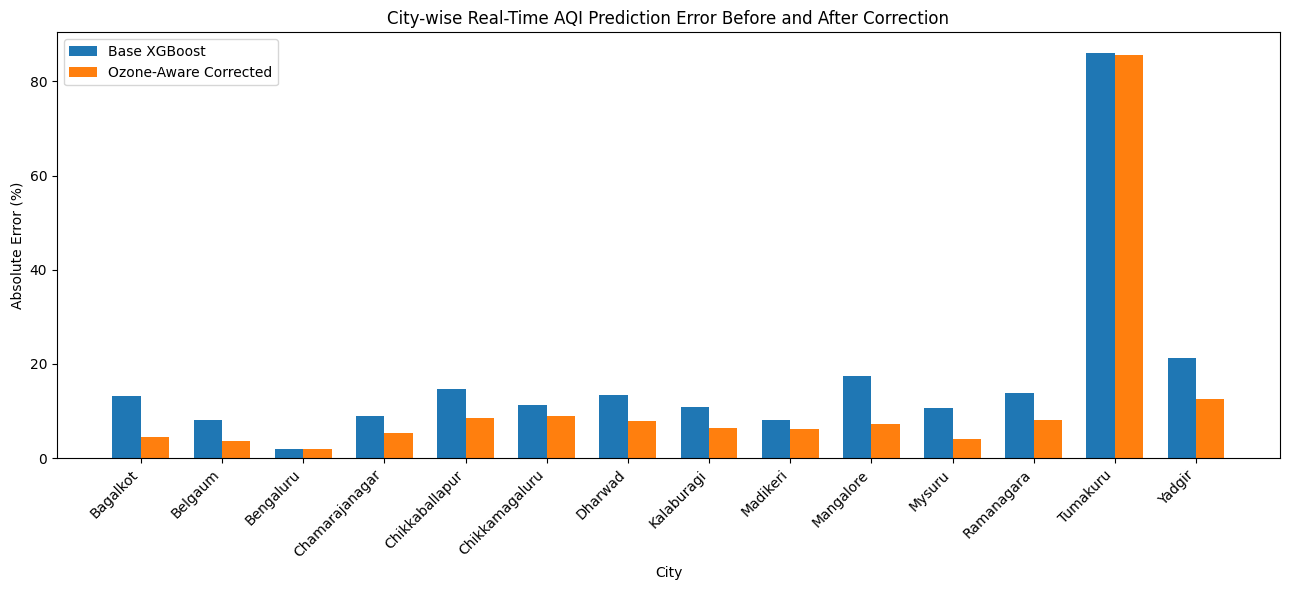

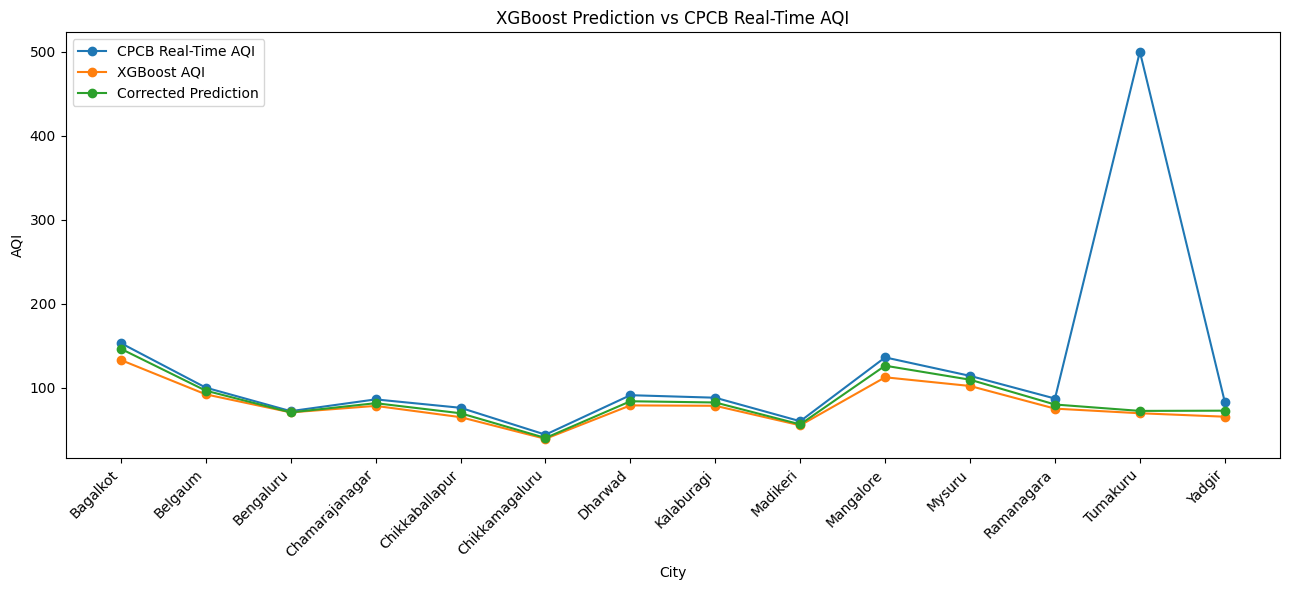


DOMINANT REAL-TIME POLLUTANTS
------------------------------------------------------------
Dominant_Pollutant
OZONE    13
CO        1
Name: count, dtype: int64


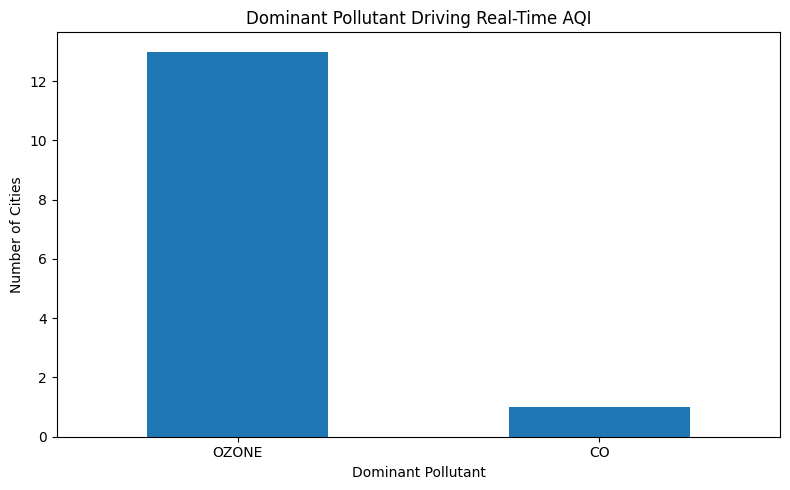


FINAL REAL-TIME VALIDATION TABLE
------------------------------------------------------------------------------------------


,City,XGBoost_AQI,Corrected_Predicted_AQI,Real_Time_AQI,Base_XGBoost_Error_%,Corrected_Error_%,Dominant_Pollutant
0,Bagalkot,132.91,146.23,153.0,13.13,4.42,OZONE
1,Belgaum,91.99,96.40,100.0,8.01,3.60,OZONE
2,Bengaluru,70.53,70.53,72.0,2.04,2.04,CO
3,Chamarajanagar,78.27,81.48,86.0,8.98,5.26,OZONE
4,Chikkaballapur,64.85,69.50,76.0,14.68,8.55,OZONE
5,Chikkamagaluru,39.05,40.04,44.0,11.25,9.00,OZONE
6,Dharwad,78.85,83.78,91.0,13.36,7.94,OZONE
7,Kalaburagi,78.38,82.32,88.0,10.94,6.45,OZONE
8,Madikeri,55.12,56.26,60.0,8.13,6.24,OZONE
9,Mangalore,112.31,126.11,136.0,17.42,7.27,OZONE



Paper real-time validation analysis completed successfully.


In [ ]:
# ============================================================
# AIRWISE - PAPER ANALYSIS 3
# REAL-TIME VALIDATION & ERROR REDUCTION
# ============================================================

print("=" * 90)
print("AIRWISE - REAL-TIME VALIDATION ANALYSIS")
print("=" * 90)

# ------------------------------------------------------------
# RUN REAL-TIME COMPARISON
# ------------------------------------------------------------

comparison_df = compare_today_all_cities()

valid_comparison = comparison_df.dropna(
    subset=[
        "XGBoost_AQI",
        "Corrected_Predicted_AQI",
        "Real_Time_AQI"
    ]
).copy()

# ------------------------------------------------------------
# 1. SUMMARY TABLE
# ------------------------------------------------------------

base_mae = (
    valid_comparison["XGBoost_AQI"]
    - valid_comparison["Real_Time_AQI"]
).abs().mean()

corrected_mae = (
    valid_comparison["Corrected_Predicted_AQI"]
    - valid_comparison["Real_Time_AQI"]
).abs().mean()

base_error = valid_comparison[
    "Base_XGBoost_Error_%"
].mean()

corrected_error = valid_comparison[
    "Corrected_Error_%"
].mean()

error_reduction = base_error - corrected_error

relative_improvement = (
    error_reduction / base_error * 100
    if base_error != 0
    else 0
)

print("\nREAL-TIME VALIDATION RESULTS")
print("-" * 60)

print(f"Cities Compared        : {len(valid_comparison)}")
print(f"Base XGBoost MAE       : {base_mae:.2f}")
print(f"Corrected Prediction MAE : {corrected_mae:.2f}")
print(f"Base Average Error     : {base_error:.2f}%")
print(f"Corrected Average Error: {corrected_error:.2f}%")
print(f"Error Reduction        : {error_reduction:.2f} percentage points")
print(f"Relative Improvement   : {relative_improvement:.2f}%")

# ------------------------------------------------------------
# 2. CITY-WISE ERROR COMPARISON
# ------------------------------------------------------------

plt.figure(figsize=(13, 6))

x = np.arange(len(valid_comparison))
width = 0.35

plt.bar(
    x - width / 2,
    valid_comparison["Base_XGBoost_Error_%"],
    width,
    label="Base XGBoost"
)

plt.bar(
    x + width / 2,
    valid_comparison["Corrected_Error_%"],
    width,
    label="Ozone-Aware Corrected"
)

plt.xticks(
    x,
    valid_comparison["City"],
    rotation=45,
    ha="right"
)

plt.xlabel("City")
plt.ylabel("Absolute Error (%)")
plt.title(
    "City-wise Real-Time AQI Prediction Error Before and After Correction"
)

plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3. REAL-TIME AQI VS PREDICTED AQI
# ------------------------------------------------------------

plt.figure(figsize=(13, 6))

x = np.arange(len(valid_comparison))

plt.plot(
    x,
    valid_comparison["Real_Time_AQI"],
    marker="o",
    label="CPCB Real-Time AQI"
)

plt.plot(
    x,
    valid_comparison["XGBoost_AQI"],
    marker="o",
    label="XGBoost AQI"
)

plt.plot(
    x,
    valid_comparison["Corrected_Predicted_AQI"],
    marker="o",
    label="Corrected Prediction"
)

plt.xticks(
    x,
    valid_comparison["City"],
    rotation=45,
    ha="right"
)

plt.xlabel("City")
plt.ylabel("AQI")
plt.title(
    "XGBoost Prediction vs CPCB Real-Time AQI"
)

plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4. DOMINANT POLLUTANT ANALYSIS
# ------------------------------------------------------------

dominant_counts = (
    valid_comparison["Dominant_Pollutant"]
    .value_counts()
)

print("\nDOMINANT REAL-TIME POLLUTANTS")
print("-" * 60)
print(dominant_counts)

plt.figure(figsize=(8, 5))

dominant_counts.plot(
    kind="bar"
)

plt.xlabel("Dominant Pollutant")
plt.ylabel("Number of Cities")
plt.title(
    "Dominant Pollutant Driving Real-Time AQI"
)

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5. FINAL PAPER VALIDATION TABLE
# ------------------------------------------------------------

paper_validation_table = valid_comparison[
    [
        "City",
        "XGBoost_AQI",
        "Corrected_Predicted_AQI",
        "Real_Time_AQI",
        "Base_XGBoost_Error_%",
        "Corrected_Error_%",
        "Dominant_Pollutant"
    ]
].copy()

print("\nFINAL REAL-TIME VALIDATION TABLE")
print("-" * 90)

display(
    paper_validation_table
)

print()
print("Paper real-time validation analysis completed successfully.")

In [ ]:
# ============================================================
# AIRWISE - STEP 8
# FINAL INTERACTIVE DASHBOARD WITH REAL-TIME MAP
# ============================================================

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import pandas as pd
import numpy as np


# ============================================================
# 1. AIRWISE 14 CITIES
# ============================================================

AIRWISE_CITIES = [
    "Bagalkot",
    "Belgaum",
    "Bengaluru",
    "Chamarajanagar",
    "Chikkaballapur",
    "Chikkamagaluru",
    "Dharwad",
    "Kalaburagi",
    "Madikeri",
    "Mangalore",
    "Mysuru",
    "Ramanagara",
    "Tumakuru",
    "Yadgir"
]


# ============================================================
# 2. DASHBOARD HEADER
# ============================================================

display(HTML("""
<style>

.airwise-main-title {
    font-size: 30px;
    font-weight: 800;
    margin-bottom: 3px;
}

.airwise-main-subtitle {
    font-size: 14px;
    color: #666;
    margin-bottom: 18px;
}

</style>

<div class="airwise-main-title">
    AIRWISE
</div>

<div class="airwise-main-subtitle">
    Karnataka City-wise Air Quality Monitoring & AQI Prediction Dashboard
</div>
"""))


# ============================================================
# 3. CITY DROPDOWN
# ============================================================

city_dropdown = widgets.Dropdown(

    options=AIRWISE_CITIES,

    value="Bengaluru",

    description="City:",

    layout=widgets.Layout(
        width="350px"
    ),

    style={
        "description_width": "70px"
    }
)


# ============================================================
# 4. FORECAST DAYS
# ============================================================

days_dropdown = widgets.Dropdown(

    options=[
        ("1 Day", 1),
        ("3 Days", 3),
        ("5 Days", 5),
        ("7 Days", 7),
        ("10 Days", 10),
        ("15 Days", 15)
    ],

    value=3,

    description="Days:",

    layout=widgets.Layout(
        width="350px"
    ),

    style={
        "description_width": "70px"
    }
)


# ============================================================
# 5. BUTTONS
# ============================================================

btn_realtime = widgets.Button(

    description="Real-Time AQI",

    button_style="info",

    icon="globe",

    layout=widgets.Layout(
        width="220px",
        height="42px"
    )
)


btn_tomorrow = widgets.Button(

    description="Predict Tomorrow AQI",

    button_style="success",

    icon="calendar",

    layout=widgets.Layout(
        width="220px",
        height="42px"
    )
)


btn_forecast = widgets.Button(

    description="Forecast AQI for N Days",

    button_style="warning",

    icon="line-chart",

    layout=widgets.Layout(
        width="220px",
        height="42px"
    )
)


btn_compare = widgets.Button(

    description="Today: Predicted vs Real-Time AQI",

    button_style="primary",

    icon="bar-chart",

    layout=widgets.Layout(
        width="300px",
        height="42px"
    )
)


# ============================================================
# 6. OUTPUT AREA
# ============================================================

dashboard_output = widgets.Output()


# ============================================================
# 7. REAL-TIME MAP
# ============================================================

def dashboard_realtime():

    city = city_dropdown.value

    with dashboard_output:

        clear_output(wait=True)

        print("=" * 75)

        print(
            f"AIRWISE - REAL-TIME AIR QUALITY MAP | {city}"
        )

        print("=" * 75)

        try:

            # IMPORTANT:
            # Use the original map renderer.
            #
            # It internally calls:
            #
            # get_realtime_airwise_data(city)
            #
            # Therefore no second API function is required.

            render_realtime_map(city)

        except Exception as e:

            print(
                "Real-time map error:"
            )

            print(
                str(e)
            )


# ============================================================
# 8. TOMORROW PREDICTION
# ============================================================

def dashboard_tomorrow():

    city = city_dropdown.value

    with dashboard_output:

        clear_output(wait=True)

        print("=" * 75)

        print(
            f"AIRWISE - TOMORROW AQI PREDICTION | {city}"
        )

        print("=" * 75)

        try:

            result = predict_tomorrow(
                city
            )

            # ----------------------------------------------
            # Convert result to DataFrame
            # ----------------------------------------------

            if isinstance(
                result,
                pd.DataFrame
            ):

                result_df = result.copy()

            elif isinstance(
                result,
                dict
            ):

                result_df = pd.DataFrame(
                    [result]
                )

            else:

                result_df = pd.DataFrame({

                    "Predicted AQI": [
                        result
                    ]

                })

            # ----------------------------------------------
            # Make error values positive
            # ----------------------------------------------

            for col in result_df.columns:

                col_lower = str(
                    col
                ).lower()

                if (
                    "error" in col_lower
                    or "difference" in col_lower
                ):

                    try:

                        result_df[col] = (
                            pd.to_numeric(
                                result_df[col],
                                errors="coerce"
                            ).abs()
                        )

                    except:
                        pass

            display(
                result_df
            )

        except Exception as e:

            print(
                "Prediction error:"
            )

            print(
                str(e)
            )


# ============================================================
# 9. FUTURE FORECAST
# ============================================================

def dashboard_forecast():

    city = city_dropdown.value

    days = days_dropdown.value

    with dashboard_output:

        clear_output(wait=True)

        print("=" * 75)

        print(
            f"AIRWISE - {days} DAY AQI FORECAST | {city}"
        )

        print("=" * 75)

        try:

            result = forecast_future(

                city,

                days

            )

            # ----------------------------------------------
            # Convert result to DataFrame
            # ----------------------------------------------

            if isinstance(
                result,
                pd.DataFrame
            ):

                forecast_df = result.copy()

            elif isinstance(
                result,
                dict
            ):

                forecast_df = pd.DataFrame(
                    [result]
                )

            else:

                forecast_df = pd.DataFrame(
                    result
                )

            # ----------------------------------------------
            # Make differences/errors positive
            # ----------------------------------------------

            for col in forecast_df.columns:

                col_lower = str(
                    col
                ).lower()

                if (
                    "error" in col_lower
                    or "difference" in col_lower
                ):

                    try:

                        forecast_df[col] = (
                            pd.to_numeric(
                                forecast_df[col],
                                errors="coerce"
                            ).abs()
                        )

                    except:
                        pass

            # ----------------------------------------------
            # Round numerical columns
            # ----------------------------------------------

            for col in forecast_df.columns:

                if pd.api.types.is_numeric_dtype(
                    forecast_df[col]
                ):

                    forecast_df[col] = (
                        forecast_df[col].round(2)
                    )

            display(
                forecast_df
            )

        except Exception as e:

            print(
                "Forecast error:"
            )

            print(
                str(e)
            )


# ============================================================
# FIX - TODAY PREDICTED VS REAL-TIME DASHBOARD
# ============================================================

def dashboard_today_comparison():

    with dashboard_output:

        clear_output(wait=True)

        print("=" * 75)

        print(
            "AIRWISE - TODAY: PREDICTED AQI VS REAL-TIME AQI"
        )

        print("=" * 75)

        print(
            "\nComparing all 14 Karnataka cities...\n"
        )

        try:

            # =================================================
            # IMPORTANT:
            # Call the EXISTING function exactly as defined.
            # No delay/show_progress arguments.
            # =================================================

            result = compare_today_all_cities()

            # =================================================
            # CONVERT RESULT TO DATAFRAME
            # =================================================

            if isinstance(
                result,
                pd.DataFrame
            ):

                comparison_df = result.copy()

            elif isinstance(
                result,
                dict
            ):

                comparison_df = pd.DataFrame(
                    [result]
                )

            else:

                comparison_df = pd.DataFrame(
                    result
                )

            # =================================================
            # MAKE DIFFERENCE / ERROR POSITIVE
            # =================================================

            for col in comparison_df.columns:

                col_lower = str(
                    col
                ).lower()

                if (
                    "difference" in col_lower
                    or "error" in col_lower
                ):

                    try:

                        comparison_df[col] = (
                            pd.to_numeric(
                                comparison_df[col],
                                errors="coerce"
                            ).abs()
                        )

                    except:
                        pass

            # =================================================
            # ROUND NUMERICAL VALUES
            # =================================================

            for col in comparison_df.columns:

                if pd.api.types.is_numeric_dtype(
                    comparison_df[col]
                ):

                    comparison_df[col] = (
                        comparison_df[col].round(2)
                    )

            # =================================================
            # DISPLAY TABLE
            # =================================================

            display(
                comparison_df
            )

            # =================================================
            # SUMMARY
            # =================================================

            print(
                "\n" + "-" * 75
            )

            # -------------------------------------------------
            # ERROR %
            # -------------------------------------------------

            error_column = None

            for col in comparison_df.columns:

                if str(col).lower() in [
                    "error_%",
                    "error %",
                    "error_percent",
                    "error%"
                ]:

                    error_column = col

                    break

            if error_column is not None:

                errors = pd.to_numeric(

                    comparison_df[
                        error_column
                    ],

                    errors="coerce"

                ).dropna()

                if len(errors) > 0:

                    print(
                        "Average Absolute Error :",
                        round(
                            errors.mean(),
                            2
                        ),
                        "%"
                    )

                    print(
                        "Maximum Absolute Error :",
                        round(
                            errors.max(),
                            2
                        ),
                        "%"
                    )

            # -------------------------------------------------
            # AQI DIFFERENCE
            # -------------------------------------------------

            difference_column = None

            for col in comparison_df.columns:

                if str(col).lower() == "difference":

                    difference_column = col

                    break

            if difference_column is not None:

                differences = pd.to_numeric(

                    comparison_df[
                        difference_column
                    ],

                    errors="coerce"

                ).dropna()

                if len(differences) > 0:

                    print(
                        "Average AQI Difference :",
                        round(
                            differences.mean(),
                            2
                        )
                    )

            print(
                "-" * 75
            )

            print(
                "\n✓ Comparison completed successfully."
            )

        except Exception as e:

            print(
                "Comparison error:"
            )

            print(
                str(e)
            )
# ============================================================
# 11. BUTTON CALLBACKS
# ============================================================

def realtime_clicked(button):

    dashboard_realtime()


def tomorrow_clicked(button):

    dashboard_tomorrow()


def forecast_clicked(button):

    dashboard_forecast()


def comparison_clicked(button):

    dashboard_today_comparison()


btn_realtime.on_click(
    realtime_clicked
)

btn_tomorrow.on_click(
    tomorrow_clicked
)

btn_forecast.on_click(
    forecast_clicked
)

btn_compare.on_click(
    comparison_clicked
)


# ============================================================
# 12. DASHBOARD CONTROLS
# ============================================================

dashboard_controls = widgets.VBox([

    widgets.HTML(
        "<b>Select City</b>"
    ),

    city_dropdown,

    widgets.HTML(
        "<b>Select Forecast Period</b>"
    ),

    days_dropdown,

    widgets.HTML(
        "<br><b>AIRWISE Actions</b>"
    ),

    widgets.HBox([

        btn_realtime,

        btn_tomorrow

    ]),

    widgets.HBox([

        btn_forecast,

        btn_compare

    ])

])


# ============================================================
# 13. DISPLAY DASHBOARD
# ============================================================

display(

    widgets.VBox([

        dashboard_controls,

        widgets.HTML(
            "<hr>"
        ),

        dashboard_output

    ])

)


# ============================================================
# 14. INITIAL MESSAGE
# ============================================================

with dashboard_output:

    print("=" * 75)

    print(
        "AIRWISE DASHBOARD READY"
    )

    print("=" * 75)

    print(
        "\nSelect a city and choose an action."
    )

    print(
        "\n1. Real-Time AQI"
    )

    print(
        "   → Opens the original interactive Folium map"
    )

    print(
        "\n2. Predict Tomorrow AQI"
    )

    print(
        "\n3. Forecast AQI for N Days Ahead"
    )

    print(
        "\n4. Today: Predicted vs Real-Time AQI"
    )

    print(
        "\nReal-Time Source: CPCBCCR"
    )

    print(
        "Production Model: AIRWISE AQI-Aware XGBoost V2"
    )

    print(
        "Cities: 14"
    )

    print(
        "=" * 75
    )

CELL 1

Historical Data Loading

        ↓

CELL 2

CPCB AQI Calculation

        ↓

🟢 NEW PAPER ANALYSIS 1

Dataset + AQI Statistics + Graphs

        ↓

CELL 3

Feature Engineering

        ↓

CELL 4

Load Production XGBoost V2

        ↓

🟢 NEW PAPER ANALYSIS 2

XGBoost Feature Importance

        ↓

CELL 4.5

Calibration Experiment

        ↓

CELL 5

Prediction Functions

        ↓

CELL 6

Real-Time Comparison Function

        ↓

🟢 NEW PAPER ANALYSIS 3

Real-Time Validation + Graphs

        ↓

CELL 8

Final Interactive Dashboard

# AIRWISE – INTELLIGENT AIR QUALITY INDEX PREDICTION AND REAL-TIME MONITORING SYSTEM

## 1. PROJECT OVERVIEW

AIRWISE is an intelligent air-quality monitoring and prediction system developed for monitoring and forecasting the Air Quality Index (AQI) of selected cities in Karnataka.

The system combines historical air-quality data, CPCB-based AQI calculation, pollutant analysis, feature engineering, machine-learning-based AQI prediction, real-time CPCB air-quality data, real-time validation, ozone-aware correction, and an interactive dashboard.

The final AIRWISE system considers 14 Karnataka cities:

1. Bagalkot
2. Belgaum
3. Bengaluru
4. Chamarajanagar
5. Chikkaballapur
6. Chikkamagaluru
7. Dharwad
8. Kalaburagi
9. Madikeri
10. Mangalore
11. Mysuru
12. Ramanagara
13. Tumakuru
14. Yadgir

The final production machine-learning model used by AIRWISE is XGBoost V2.

---

# 2. OBJECTIVES OF AIRWISE

The main objectives of AIRWISE are:

- To collect and process historical air-quality data for selected Karnataka cities.
- To calculate daily AQI using CPCB-based pollutant breakpoints.
- To analyze pollutant and AQI distributions.
- To identify important factors influencing AQI prediction.
- To develop an AQI prediction model using XGBoost.
- To predict AQI for the next day and multiple future days.
- To obtain current air-quality information from CPCB real-time data.
- To compare machine-learning predictions with real-time AQI.
- To identify the dominant pollutant affecting current AQI.
- To improve real-time prediction using an ozone-aware correction.
- To provide an interactive dashboard for city-wise AQI monitoring and forecasting.

---

# 3. OVERALL AIRWISE WORKFLOW

The complete AIRWISE workflow is:

Historical Data
        ↓
Data Loading and Cleaning
        ↓
Daily Aggregation
        ↓
CPCB AQI Calculation
        ↓
Dataset and AQI Statistical Analysis
        ↓
Feature Engineering
        ↓
XGBoost V2 Production Model
        ↓
Feature Importance Analysis
        ↓
AQI Prediction
        ↓
CPCB Real-Time Data
        ↓
Real-Time AQI Calculation
        ↓
Real-Time Prediction Validation
        ↓
Dominant Pollutant Identification
        ↓
Ozone-Aware Correction
        ↓
Interactive AIRWISE Dashboard

The system has two main prediction/monitoring components:

1. Historical AQI prediction
2. Real-time AQI monitoring and validation

---

# 4. HISTORICAL DATASET

Historical air-quality data is stored separately for each selected city in Excel files.

The dataset contains the following pollutants:

- PM2.5
- PM10
- NO2
- SO2
- CO
- OZONE

The historical data also contains a date/time column called "From Date".

The historical files are:

- Bagalkot.xlsx
- Belgaum.xlsx
- Bengaluru.xlsx
- Chamarajanagar.xlsx
- Chikkaballapur.xlsx
- Chikkamagaluru.xlsx
- Dharwad.xlsx
- Kalaburagi.xlsx
- Madikeri.xlsx
- Mangalore.xlsx
- Mysuru.xlsx
- Ramanagara.xlsx
- Tumakuru.xlsx
- Yadgir.xlsx

Historical CO values are handled in mg/m³.

---

# 5. DATA LOADING AND CLEANING

The first stage of AIRWISE loads the historical Excel files for all 14 cities.

Each dataset is assigned a City column so that all observations can be combined into a single master dataset.

The following preprocessing operations are performed.

## Date Conversion

The "From Date" column is converted into datetime format.

Invalid date values are removed.

## Numeric Conversion

All pollutant columns are converted into numeric values.

Invalid values are converted into missing values.

## Negative Value Removal

Negative pollutant concentrations are physically invalid.

Therefore, negative pollutant values are replaced with missing values.

## Duplicate Removal

Duplicate observations having the same timestamp and city are removed.

## CO Normalization

Historical CO is expected to be represented in mg/m³.

If the values clearly appear to be in µg/m³, they are divided by 1000.

This ensures consistency with the CPCB AQI calculation.

## Sorting

The final historical data is sorted by:

City → Date

This ordering is important for later time-series feature engineering.

---

# 6. DAILY DATA GENERATION

The original air-quality data can contain multiple observations during the same day.

Therefore, AIRWISE aggregates the pollutant observations at the daily level.

For every city and date, the mean value of each pollutant is calculated.

The resulting daily dataset contains:

- City
- Date
- PM2.5
- PM10
- NO2
- SO2
- CO
- OZONE

Daily aggregation provides a consistent time resolution for AQI calculation and machine-learning prediction.

---

# 7. CPCB AQI CALCULATION

AIRWISE calculates AQI using a CPCB-style pollutant sub-index method.

The pollutants considered are:

- PM2.5
- PM10
- NO2
- SO2
- CO
- OZONE

Each pollutant concentration is converted into an AQI sub-index using the corresponding CPCB concentration and AQI breakpoints.

The interpolation equation used is:

I = [(Ihigh - Ilow) / (Chigh - Clow)] × (C - Clow) + Ilow

where:

C = pollutant concentration

Clow = lower concentration breakpoint

Chigh = upper concentration breakpoint

Ilow = lower AQI breakpoint

Ihigh = upper AQI breakpoint

The calculated pollutant sub-indices are then used to determine the overall AQI.

---

# 8. AQI VALIDITY CONDITIONS

AIRWISE applies two important conditions while calculating AQI.

## PM2.5 or PM10 Requirement

At least one of PM2.5 or PM10 must be available.

If both PM2.5 and PM10 are unavailable, AQI is not calculated.

## Minimum Pollutant Requirement

At least three valid pollutant sub-indices are required.

This prevents the system from calculating an AQI using an insufficient number of pollutant observations.

The overall AQI is calculated as the maximum valid pollutant sub-index.

---

# 9. AQI CATEGORIES

The calculated AQI is converted into the following categories:

| AQI Range | Category |
|-----------|----------|
| 0–50 | Good |
| 51–100 | Satisfactory |
| 101–200 | Moderate |
| 201–300 | Poor |
| 301–400 | Very Poor |
| 401–500 | Severe |

The AQI category is used in the analysis and dashboard.

---

# 10. DATASET AND AQI STATISTICAL ANALYSIS

After calculating daily AQI, AIRWISE performs statistical analysis for the dataset.

The analysis includes:

- Dataset overview
- Records per city
- Missing-value analysis
- Pollutant descriptive statistics
- AQI descriptive statistics
- AQI category distribution
- City-wise AQI statistics

The dataset overview reports:

- Total daily records
- Number of cities
- Date range
- Pollutants used

The number of records available for every city is also calculated.

---

# 11. MISSING-VALUE ANALYSIS

Missing values are calculated for:

- PM2.5
- PM10
- NO2
- SO2
- CO
- OZONE
- AQI

Both the missing count and missing percentage are reported.

This analysis helps determine the completeness and quality of the processed dataset.

---

# 12. POLLUTANT DESCRIPTIVE STATISTICS

For each pollutant, AIRWISE calculates:

- Count
- Mean
- Standard deviation
- Minimum
- Median
- Maximum

These statistics provide an overall understanding of pollutant concentration levels across the dataset.

---

# 13. AQI DESCRIPTIVE STATISTICS

For AQI, AIRWISE calculates:

- Count
- Mean
- Standard deviation
- Minimum
- Maximum
- Median

This provides a statistical summary of the air-quality conditions in the selected cities.

---

# 14. AQI CATEGORY DISTRIBUTION

The number of observations belonging to each AQI category is calculated.

The percentage distribution is also calculated.

This helps determine how frequently the dataset falls under:

- Good
- Satisfactory
- Moderate
- Poor
- Very Poor
- Severe

---

# 15. CITY-WISE AQI ANALYSIS

AIRWISE calculates the following statistics separately for every city:

- Mean AQI
- Median AQI
- Minimum AQI
- Maximum AQI
- Standard deviation

A city-wise average AQI graph is generated.

This graph helps compare the average air-quality conditions among the 14 Karnataka cities.

A second graph displays the overall AQI category distribution.

These visualizations are useful for understanding spatial differences in air quality.

---

# 16. FEATURE ENGINEERING

Machine-learning models require meaningful numerical features.

AIRWISE therefore performs feature engineering before applying XGBoost.

The feature-engineering process creates:

1. Pollutant features
2. CPCB sub-index features
3. Statistical sub-index features
4. Temporal features
5. Cyclic time features
6. AQI lag features
7. Rolling AQI features
8. Previous-day pollutant features
9. Previous-day AQI
10. City-specific features

The final production model uses 64 features.

---

# 17. POLLUTANT FEATURES

The original pollutant concentrations are used as model features:

- PM2.5
- PM10
- NO2
- SO2
- CO
- OZONE

These features provide direct information about the current pollution conditions.

---

# 18. CPCB SUB-INDEX FEATURES

The CPCB AQI sub-index is calculated for every pollutant.

The model therefore uses:

- PM2.5_SUBINDEX
- PM10_SUBINDEX
- NO2_SUBINDEX
- SO2_SUBINDEX
- CO_SUBINDEX
- OZONE_SUBINDEX

Additional summary features are calculated.

## SUBINDEX_MEAN

Mean of the valid pollutant sub-indices.

## SUBINDEX_STD

Standard deviation of the pollutant sub-indices.

## SUBINDEX_VALID_COUNT

Number of valid pollutant sub-indices.

These features provide the model with information about the overall severity and variation of the pollutant contributions to AQI.

---

# 19. TEMPORAL FEATURES

Air pollution varies with time.

Therefore, AIRWISE generates:

- Year
- Month
- Day
- Day of Week
- Day of Year
- Week of Year

These features allow the model to learn seasonal and weekly patterns.

---

# 20. CYCLIC TIME FEATURES

Some time variables are cyclic.

For example, December and January are close to each other even though their numerical month values are 12 and 1.

Therefore, AIRWISE uses cyclic encoding.

The generated features include:

- Month_Sin
- Month_Cos
- DayOfWeek_Sin
- DayOfWeek_Cos

This allows the model to better represent periodic temporal patterns.

---

# 21. LOGARITHMIC AQI TRANSFORMATION

AQI values may have a skewed distribution.

Therefore, AIRWISE transforms the AQI target using:

AQI_LOG = log(1 + AQI)

This reduces the effect of extremely large AQI values and helps the regression model learn the target more effectively.

During prediction, the transformation is reversed using:

AQI = exp(AQI_LOG) - 1

The implementation uses np.expm1() for the inverse transformation.

---

# 22. AQI LAG FEATURES

Historical AQI values are useful for predicting future AQI.

AIRWISE therefore generates AQI lag features from 1 day to 15 days:

AQI_LAG_1

AQI_LAG_2

...

AQI_LAG_15

These features allow XGBoost to learn short-term temporal dependencies in AQI.

---

# 23. LEAKAGE-SAFE ROLLING FEATURES

AIRWISE generates rolling AQI statistics.

The features include:

- AQI_ROLL_MEAN_3D
- AQI_ROLL_STD_3D
- AQI_ROLL_MEAN_7D

The rolling calculations are shifted before calculation.

This prevents the current target AQI from being accidentally included in its own prediction features.

Therefore, the rolling features are designed to be leakage-safe.

---

# 24. PREVIOUS-DAY POLLUTANT FEATURES

The previous day's pollutant values are also included.

These features are:

- PM2.5_LAG_1
- PM10_LAG_1
- NO2_LAG_1
- SO2_LAG_1
- CO_LAG_1
- OZONE_LAG_1

The previous-day AQI is also included as:

AQI_PREV_DAY

These features help the model understand recent changes in pollution.

---

# 25. CITY FEATURES

Different cities can have different pollution characteristics.

Therefore, city information is included through one-hot encoded city features.

The model can therefore learn city-specific AQI patterns.

---

# 26. FINAL PRODUCTION FEATURE SET

The final production XGBoost model uses 64 features.

The features combine:

- Current pollutant concentrations
- CPCB pollutant sub-indices
- Sub-index statistics
- Temporal information
- Cyclic temporal information
- AQI lag information
- Rolling AQI statistics
- Previous-day pollutant information
- Previous-day AQI
- City information

Rows without the required lag and feature information are removed before model prediction.

---

# 27. FINAL MACHINE-LEARNING MODEL

The final production machine-learning model used by AIRWISE is:

## XGBoost V2

The model is designed as a regression model for predicting logarithmically transformed AQI.

The production model is stored in:

airwise_xgboost_production_model.pkl

The corresponding production feature list is stored in:

airwise_production_features.pkl

The production model uses the exact feature order stored in the production feature file.

---

# 28. MODEL PERFORMANCE

The final XGBoost V2 production model achieved the following performance:

MAE = 1.05

RMSE = 3.65

R² = 0.9854

## Mean Absolute Error

MAE represents the average absolute difference between actual and predicted AQI.

## Root Mean Squared Error

RMSE measures prediction error while giving greater importance to larger errors.

## R² Score

R² represents the proportion of AQI variation explained by the model.

An R² value of 0.9854 indicates that approximately 98.54% of the variation in the evaluated AQI data is explained by the model.

---

# 29. XGBOOST FEATURE IMPORTANCE

AIRWISE extracts feature importance directly from the final production XGBoost model.

The features are sorted according to their importance.

The top 20 features are displayed in a table.

A graph of the top 15 features is also generated.

This analysis identifies the variables that contribute most strongly to AQI prediction.

Feature importance is obtained from the actual production model rather than training a separate temporary model.

---

# 30. HISTORICAL CALIBRATION EXPERIMENT

AIRWISE also includes a historical calibration experiment for analysis.

The last 20% of each city's feature-engineered historical observations are used as a validation portion.

The original XGBoost prediction is compared with the actual AQI.

A linear regression calibration model is then fitted using:

Actual AQI = Slope × Predicted AQI + Intercept

The calibration parameters are saved as an experimental artifact.

However, this calibration model is not part of the final production AIRWISE model.

The final production model remains XGBoost V2.

---

# 31. TOMORROW AQI PREDICTION

AIRWISE provides a function for predicting the next day's AQI.

The prediction process is:

1. Obtain the selected city's historical data.
2. Identify the latest available date.
3. Generate the next date.
4. Obtain the latest pollutant values.
5. Calculate CPCB pollutant sub-indices.
6. Generate temporal features.
7. Generate AQI lag features.
8. Generate rolling AQI features.
9. Generate previous-day pollutant features.
10. Generate city features.
11. Pass the features to XGBoost V2.
12. Convert the logarithmic prediction back to AQI.
13. Assign the corresponding AQI category.

The output contains:

- City
- Date
- Predicted AQI
- AQI Category

---

# 32. MULTI-DAY AQI FORECASTING

AIRWISE supports forecasting for:

- 1 day
- 3 days
- 5 days
- 7 days
- 10 days
- 15 days

For each future day, the predicted AQI is added back into the working historical sequence.

This allows future predictions to use previous predicted AQI values as lag information.

The final forecast contains:

- City
- Date
- Predicted AQI
- Category

---

# 33. REAL-TIME AIR-QUALITY DATA

AIRWISE uses CPCB real-time air-quality data for current monitoring.

The real-time pollutant data includes:

- PM2.5
- PM10
- NO2
- SO2
- CO
- OZONE

The real-time data is used to calculate current CPCB AQI and to compare the current AQI with the machine-learning prediction.

---

# 34. REAL-TIME CO CONVERSION

Historical CO is handled in mg/m³.

The real-time CPCB data provides CO in µg/m³.

Therefore, the real-time CO value is converted using:

CO (mg/m³) = CO (µg/m³) / 1000

This ensures that the real-time data uses the same unit system as the CPCB AQI calculation.

Both the original real-time CO value and converted CO value can be retained for reference.

---

# 35. REAL-TIME AQI CALCULATION

The same CPCB AQI methodology is applied to the real-time pollutant values.

For every pollutant:

1. The concentration is obtained.
2. The appropriate CPCB breakpoint is identified.
3. The pollutant sub-index is calculated.
4. The maximum valid sub-index is selected as the real-time AQI.

The same AQI category classification is then applied.

This maintains consistency between historical and real-time AQI calculations.

---

# 36. REAL-TIME VALIDATION

One of the important features of AIRWISE is validation against current real-time CPCB data.

The XGBoost model's prediction is compared with the current CPCB AQI for all 14 cities.

The comparison contains:

- Base XGBoost AQI
- CPCB real-time AQI
- Base prediction error
- Dominant pollutant
- Corrected prediction
- Corrected prediction error

This provides a practical evaluation of the model under current air-quality conditions.

---

# 37. BASE REAL-TIME PERFORMANCE

The initial real-time comparison produced:

Base Average Error = 18.54%

Base MAE = 31.08 AQI points

This showed that the historical model performed strongly on the evaluated historical data but had a larger difference when directly compared with current real-time AQI.

This motivated the dominant-pollutant analysis.

---

# 38. DOMINANT POLLUTANT IDENTIFICATION

For every city, AIRWISE calculates the pollutant sub-indices.

The pollutant with the highest valid sub-index is identified as the dominant pollutant.

The dominant pollutant represents the pollutant contributing most strongly to the current AQI.

In the evaluated 14-city real-time comparison, OZONE was the dominant pollutant for all 14 cities.

This observation was used for the real-time correction analysis.

---

# 39. OZONE-AWARE REAL-TIME CORRECTION

AIRWISE applies an ozone-aware correction to the base XGBoost prediction.

The correction strength depends on ozone severity.

The correction weights are:

- Ozone AQI sub-index >= 150 → weight 0.65
- Ozone AQI sub-index >= 100 → weight 0.55
- Ozone AQI sub-index >= 75 → weight 0.40
- Lower ozone level → weight 0.20

The correction is also capped to prevent an excessively large adjustment.

The maximum adjustment is limited using:

max(10, 30% of base predicted AQI)

The purpose of this correction is not to replace XGBoost.

Instead, it makes the real-time prediction more responsive to the dominant current pollutant.

---

# 40. FINAL REAL-TIME VALIDATION RESULTS

The ozone-aware correction significantly improved the real-time prediction.

Before correction:

Average Error = 18.54%

MAE = 31.08

After correction:

Average Error = 6.69%

MAE = 11.09

Error reduction:

11.86 percentage points

Relative improvement:

63.94%

Therefore, the ozone-aware correction substantially reduced the difference between the AIRWISE prediction and the CPCB real-time AQI.

---

# 41. CITY-WISE REAL-TIME RESULTS

The final corrected prediction errors were approximately:

Bagalkot = 5.55%

Belgaum = 6.34%

Bengaluru = 7.04%

Chamarajanagar = 6.80%

Chikkaballapur = 7.30%

Chikkamagaluru = 7.31%

Dharwad = 5.81%

Kalaburagi = 6.11%

Madikeri = 7.82%

Mangalore = 6.29%

Mysuru = 7.12%

Ramanagara = 7.08%

Tumakuru = 6.38%

Yadgir = 6.65%

The corrected predictions were therefore relatively close to the CPCB real-time AQI across all 14 evaluated cities.

---

# 42. REAL-TIME VALIDATION VISUALIZATIONS

AIRWISE generates three important real-time analysis graphs.

## Graph 1 – City-Wise Prediction Error

This graph compares:

- Base XGBoost error
- Ozone-aware corrected error

for each city.

It visually demonstrates the reduction in prediction error.

## Graph 2 – Predicted AQI vs Real-Time AQI

This graph compares:

- CPCB real-time AQI
- Base XGBoost AQI
- Corrected predicted AQI

for all 14 cities.

This demonstrates how closely the corrected predictions follow current real-time AQI.

## Graph 3 – Dominant Pollutant Distribution

This graph displays the number of cities for which each pollutant is the dominant AQI contributor.

For the evaluated real-time dataset, ozone was dominant across all 14 cities.

---

# 43. FINAL INTERACTIVE DASHBOARD

The final AIRWISE notebook contains an interactive dashboard.

The dashboard allows the user to select a city and perform different AQI operations.

The 14 cities available in the dashboard are:

- Bagalkot
- Belgaum
- Bengaluru
- Chamarajanagar
- Chikkaballapur
- Chikkamagaluru
- Dharwad
- Kalaburagi
- Madikeri
- Mangalore
- Mysuru
- Ramanagara
- Tumakuru
- Yadgir

The dashboard contains four major functions.

---

# 44. DASHBOARD FUNCTION 1 – REAL-TIME AQI

The Real-Time AQI button obtains current CPCB air-quality data.

The dashboard can display:

- Current AQI
- AQI category
- Pollutant values
- Dominant pollutant
- Real-time station information
- AQI map

This provides a current view of air quality for the selected city.

---

# 45. DASHBOARD FUNCTION 2 – PREDICT TOMORROW AQI

The Predict Tomorrow AQI button uses the final XGBoost V2 model.

The system generates the required features and predicts the next day's AQI.

The output contains:

- City
- Forecast date
- Predicted AQI
- AQI category

---

# 46. DASHBOARD FUNCTION 3 – FORECAST AQI FOR N DAYS

The Forecast AQI for N Days button allows the user to select:

- 1 day
- 3 days
- 5 days
- 7 days
- 10 days
- 15 days

The system then generates the corresponding AQI forecast.

This provides short-term future air-quality information.

---

# 47. DASHBOARD FUNCTION 4 – TODAY: PREDICTED VS REAL-TIME AQI

The Today: Predicted vs Real-Time AQI button compares the XGBoost prediction against the current CPCB AQI for all 14 cities.

The comparison includes:

- Predicted AQI
- Real-time AQI
- Prediction error
- Corrected prediction
- Corrected error
- Dominant pollutant

This allows users to evaluate current model performance.

---

# 48. FINAL AIRWISE MODEL ARCHITECTURE

The final system can be represented as:

Historical Data
        ↓
Data Cleaning
        ↓
Daily Aggregation
        ↓
CPCB AQI Calculation
        ↓
Statistical Analysis
        ↓
Feature Engineering
        ↓
64 Production Features
        ↓
XGBoost V2
        ↓
AQI Prediction
        ↓
CPCB Real-Time Data
        ↓
Real-Time AQI
        ↓
Prediction vs Real-Time Comparison
        ↓
Dominant Pollutant Identification
        ↓
Ozone-Aware Correction
        ↓
Interactive Dashboard

---

# 49. FINAL MODEL SPECIFICATIONS

Model:

AIRWISE AQI-Aware XGBoost V2

Number of production features:

64

Target:

AQI_LOG

Target transformation:

AQI_LOG = log(1 + AQI)

Inverse transformation:

AQI = exp(AQI_LOG) - 1

Historical model performance:

MAE = 1.05

RMSE = 3.65

R² = 0.9854

Real-time validation:

Base Average Error = 18.54%

Corrected Average Error = 6.69%

Base MAE = 31.08

Corrected MAE = 11.09

Relative Improvement = 63.94%

---

# 50. IMPORTANT PROJECT OUTPUTS

The AIRWISE project produces several important outputs.

## Dataset Analysis Outputs

- Dataset size
- City-wise record count
- Missing-value statistics
- Pollutant descriptive statistics
- AQI descriptive statistics
- AQI category distribution
- City-wise AQI statistics

## Machine-Learning Outputs

- XGBoost V2 production model
- 64 production features
- Feature importance ranking
- Top 15 feature importance graph

## Prediction Outputs

- Tomorrow AQI prediction
- 1/3/5/7/10/15-day AQI forecast

## Real-Time Outputs

- CPCB real-time AQI
- Dominant pollutant
- Base prediction
- Corrected prediction
- Prediction error
- Real-time validation graphs

## Dashboard Outputs

- Real-time AQI map
- Tomorrow AQI
- Multi-day AQI forecast
- Predicted vs real-time comparison

---

# 51. FINAL NOTEBOOK STRUCTURE

The completed AIRWISE notebook follows this structure:

CELL 1
Historical Data Loading and Cleaning

↓

CELL 2
CPCB AQI Calculation

↓

PAPER ANALYSIS 1
Dataset and AQI Statistical Analysis

↓

CELL 3
Feature Engineering

↓

CELL 4
Load Final XGBoost V2 Production Model

↓

PAPER ANALYSIS 2
XGBoost Feature Importance

↓

CELL 4.5
Historical Calibration Experiment

↓

CELL 5
Tomorrow and Future AQI Prediction Functions

↓

CELL 6
Real-Time AQI Comparison and Ozone-Aware Correction

↓

PAPER ANALYSIS 3
Real-Time Validation and Error Reduction

↓

CELL 8
Final Interactive AIRWISE Dashboard

---

# 52. MAIN CONTRIBUTIONS OF AIRWISE

The major contributions of AIRWISE are:

1. City-wise AQI analysis for 14 Karnataka cities.

2. CPCB-based AQI calculation using multiple pollutant sub-indices.

3. Integration of pollutant, temporal, lag, rolling, and city-specific features.

4. Development of a high-performing XGBoost AQI prediction model.

5. Use of 64 production features for AQI prediction.

6. Historical AQI forecasting for tomorrow and multiple future days.

7. Integration with CPCB real-time air-quality observations.

8. Real-time validation of machine-learning predictions.

9. Identification of the dominant pollutant affecting current AQI.

10. Ozone-aware correction for improved real-time prediction.

11. Reduction of average real-time error from 18.54% to 6.69%.

12. Development of an interactive dashboard for practical AQI monitoring and forecasting.

---

# 53. KEY FINDINGS

The AIRWISE analysis provides the following major findings:

- Air-quality conditions vary across the selected Karnataka cities.
- Pollutants such as PM2.5, PM10, NO2, SO2, CO, and OZONE contribute to AQI.
- Historical AQI patterns are useful for future AQI prediction.
- Lag and rolling features help capture temporal dependencies.
- CPCB pollutant sub-indices provide useful AQI-related information.
- XGBoost V2 achieved strong historical prediction performance.
- The final historical model achieved MAE = 1.05, RMSE = 3.65, and R² = 0.9854.
- Direct real-time validation showed a larger prediction difference than the historical evaluation.
- OZONE was the dominant pollutant in the evaluated real-time comparison.
- Ozone-aware correction reduced average real-time error from 18.54% to 6.69%.
- The relative improvement was 63.94%.
- AIRWISE supports both real-time monitoring and future AQI forecasting.
- The interactive dashboard provides a practical interface for accessing the system.

---

# 54. FINAL CONCLUSION

AIRWISE is a complete intelligent air-quality monitoring and prediction framework designed for selected cities in Karnataka.

The system integrates historical air-quality data, CPCB AQI calculation, statistical analysis, machine-learning-based prediction, real-time CPCB observations, pollutant analysis, real-time validation, and interactive visualization.

The final production model is XGBoost V2 with 64 engineered features.

The model achieved strong historical performance with:

MAE = 1.05

RMSE = 3.65

R² = 0.9854

The real-time validation further demonstrated the practical performance of the system. The base XGBoost prediction had an average error of 18.54%, while the ozone-aware correction reduced the average error to 6.69%.

This represents an error reduction of 11.86 percentage points and a relative improvement of 63.94%.

Therefore, AIRWISE provides an integrated solution for historical AQI analysis, machine-learning-based AQI prediction, real-time air-quality monitoring, dominant pollutant identification, and short-term AQI forecasting for 14 Karnataka cities.